In [1]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u

SED_KEV_TO_ERG = u.keV.to(u.erg)
KEV_TO_MEV = u.keV.to(u.MeV)
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline


14:23:56 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=996898;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=498736;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=33249;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=480032;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=824440;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=305614;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

14:23:57 INFO      Starting 3ML!                                                                     ]8;id=999602;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=191474;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=671415;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=277486;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=907781;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=85246;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=71397;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=147087;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=695268;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=694100;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=477012;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=557684;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=386746;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=366957;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from cosipy.event_selection import GoodTimeInterval
from agn_cosi_fit_utils import draw_energy_hist_mev, open_spacecraft_history, scale_spacecraft_livetime

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
source_coord = SkyCoord(l=155.077, b=75.063, frame="galactic", unit="deg")
fov_cut = 60 * u.deg

full_sc_orientation = open_spacecraft_history(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    full_sc_orientation,
    fov_cut,
    earth_occ=False,
)
sc_orientation = full_sc_orientation.apply_gti(source_gti)

print(f"NGC 4151 FOV cut: {fov_cut.to_value(u.deg):.0f} deg")
print(f"Selected livetime: {sc_orientation.cumulative_livetime().to_value(u.s):,.1f} s")

NGC 4151 FOV cut: 60 deg
Selected livetime: 980,415.0 s


In [3]:
dr = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

In [4]:
multiplier_4151 = 1
exposure_4151 = multiplier_4151 * 3

# Scale count histograms and response livetime together; keep source flux intrinsic.
sc_orientation = scale_spacecraft_livetime(sc_orientation, multiplier_4151)

# Source Model Plots

## Cutoff Power Law (Thermal)

#### NGC 4151 (200 keV)

In [5]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

#### NGC 4151 (1000 keV)

In [6]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

# Spectral Fitting

In [7]:
bat_rsp_ec200 = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/swiftbat_survey_full.rsp"
bat_pha_ec200 = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/SWIFT_J1210.5+3924_resp.pha"

bat_rsp_ec1000 = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/Simulations/BAT_157m_swiftbat_survey_full_157m.rsp"
bat_pha_ec1000 = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/Simulations/simulate_bat_ec_1000_gamma_1dot75.pha"

bat_ec200 = OGIPLike("BAT", observation=bat_pha_ec200, response=bat_rsp_ec200)
bat_ec1000 = OGIPLike("BAT", observation=bat_pha_ec1000, response=bat_rsp_ec1000)

bat_ec200.set_active_measurements("60-200")
bat_ec1000.set_active_measurements("60-200")

# bat_ec200.view_count_spectrum()
# bat_ec1000.view_count_spectrum()

14:24:05 INFO      Auto-probed noise models:                                                    ]8;id=742875;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=718494;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=123695;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=879987;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=355438;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=915446;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Auto-probed noise models:                                                    ]8;id=398859;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=893675;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=235642;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=866559;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=808916;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=463187;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 60-200 translates to channels 4-8                                     ]8;id=852256;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=635667;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      Range 60-200 translates to channels 4-8                                     ]8;id=797590;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=554393;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

In [8]:
nustar_fpma = OGIPLike("nustar_fpma", observation="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.pha", background="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_bk.pha", response="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.rmf", arf_file="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.arf")

nustar_fpma.set_active_measurements("30-79")
# nustar_fpma.view_count_spectrum()

nustar_fpmb = OGIPLike("nustar_fpmb", observation="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.pha", background="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_bk.pha", response="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.rmf", arf_file="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.arf")

nustar_fpmb.set_active_measurements("30-79")
# nustar_fpmb.view_count_spectrum()

nustar_fpma_ec1000 = OGIPLike("nustar_fpma", observation="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.pha", background="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_bk.pha", response="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.rmf", arf_file="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.arf")

nustar_fpma_ec1000.set_active_measurements("30-79")
# nustar_fpma_ec1000.view_count_spectrum()

nustar_fpmb_ec1000 = OGIPLike("nustar_fpmb", observation="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.pha", background="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_bk.pha", response="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.rmf", arf_file="/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.arf")

nustar_fpmb_ec1000.set_active_measurements("30-79")
# nustar_fpmb_ec1000.view_count_spectrum()

14:24:07 INFO      Auto-probed noise models:                                                    ]8;id=693904;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=994304;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: poisson                                                       ]8;id=897071;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=223507;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: poisson                                                        ]8;id=252236;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=501887;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 30-79 translates to channels 709-1934                                 ]8;id=101791;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=213992;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

14:24:08 INFO      Auto-probed noise models:                                                    ]8;id=627369;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=857540;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

...

         INFO      Range 30-79 translates to channels 709-1934                                 ]8;id=447181;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=242190;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

14:24:11 INFO      Auto-probed noise models:                                                    ]8;id=60754;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=344458;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: poisson                                                       ]8;id=247569;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=739735;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: poisson                                                        ]8;id=760583;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=504200;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 30-79 translates to channels 709-1934                                 ]8;id=112442;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=139969;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

In [9]:
import json

sensitivity_dir = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble")
ec200_manifest_file = sensitivity_dir / "Case1_ec200" / f"NGC4151_ec200_TH_median_realization_{exposure_4151}months.json"
if not ec200_manifest_file.exists():
    raise FileNotFoundError(f"Run the Case1_ec200 sensitivity notebook first: {ec200_manifest_file}")
with ec200_manifest_file.open() as stream:
    ec200_manifest = json.load(stream)
NGC4151_ec200 = Histogram.open(ec200_manifest["source_expectation_file"])
NGC4151_ec200_bkg = Histogram.open(ec200_manifest["median_data_file"])
bkg = Histogram.open("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5") * multiplier_4151

# Collapse the background time axis and match the source histogram metadata.
bkg = bkg.project("Em", "Phi", "PsiChi")
NGC4151_ec200.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec200 = NGC4151_ec200.to(
    unit=bkg.unit,
    update=False,
)

NGC4151_ec200_bkg.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec200_bkg = NGC4151_ec200_bkg.to(unit=bkg.unit, update=False)


In [10]:
ec1000_manifest_file = sensitivity_dir / "Case1_ec1000" / f"NGC4151_ec1000_TH_median_realization_{exposure_4151}months.json"
if not ec1000_manifest_file.exists():
    raise FileNotFoundError(f"Run the Case1_ec1000 sensitivity notebook first: {ec1000_manifest_file}")
with ec1000_manifest_file.open() as stream:
    ec1000_manifest = json.load(stream)
NGC4151_ec1000 = Histogram.open(ec1000_manifest["source_expectation_file"])
NGC4151_ec1000_bkg = Histogram.open(ec1000_manifest["median_data_file"])
NGC4151_ec1000.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec1000 = NGC4151_ec1000.to(
    unit=bkg.unit,
    update=False,
)

NGC4151_ec1000_bkg.axes["Em"].axis_scale = bkg.axes["Em"].axis_scale
NGC4151_ec1000_bkg = NGC4151_ec1000_bkg.to(unit=bkg.unit, update=False)


## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [11]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

bkg_par_ec1000 = Parameter("background_cosi_ec1000",                           # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

cosi_ec1000 = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par_ec1000,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

### Powerlaw with energy cutoff fit

In [12]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
# spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-8
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 100 # keep these relatively the same
spectrum_cpl.xc.max_value = 10000 # change to 1000
spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_cpl.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

source1 = PointSource("source1",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl)    # Spectral model

In [13]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1000. * u.keV
index = -1.75

spectrum_cpl_ec1000 = Cutoff_powerlaw()

spectrum_cpl_ec1000.K.value = K.value
spectrum_cpl_ec1000.piv.value = piv.value
spectrum_cpl_ec1000.xc.value = xc.value
spectrum_cpl_ec1000.index.value = index
# spectrum_cpl_ec1000.index.fix = True

# Harsher Parameters
spectrum_cpl_ec1000.K.min_value = 1e-8
spectrum_cpl_ec1000.K.max_value = 1e-2
spectrum_cpl_ec1000.xc.min_value = 100 # keep these relatively the same
spectrum_cpl_ec1000.xc.max_value = 10000 # change to 1000
spectrum_cpl_ec1000.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_cpl_ec1000.index.max_value = 1

# spectrum_cpl_ec1000.K.delta = 0.05
# spectrum_cpl_ec1000.xc.delta = 10
# spectrum_cpl_ec1000.index.delta = 0.15

spectrum_cpl_ec1000.K.unit = K.unit
spectrum_cpl_ec1000.piv.unit = piv.unit
spectrum_cpl_ec1000.xc.unit = xc.unit

source2 = PointSource("source2",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl_ec1000)    # Spectral model

## Just Thermal Fit

In [14]:
# # Optional: if you want to call get_log_like manually, then you also need to set the model manually
# # 3ML does this internally during the fit though
model = Model(source1)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model_ec1000 = Model(source2)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

cosi.set_model(model)
cosi_ec1000.set_model(model_ec1000)

### Joint Fit

In [15]:
# bat_ec200.use_effective_area_correction(0.2, 1.8)
# plugins = DataList(bat_ec200, cosi)

# bat_ec1000.use_effective_area_correction(0.2, 1.8)
# plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000)

### Joint-Fit (NuSTAR)

In [16]:
nustar_fpma.use_effective_area_correction(0.2, 1.8)
nustar_fpmb.use_effective_area_correction(0.2, 1.8)
bat_ec200.use_effective_area_correction(0.2, 1.8)
plugins = DataList(bat_ec200, cosi, nustar_fpma, nustar_fpmb)
bat_ec1000.use_effective_area_correction(0.2, 1.8)
nustar_fpma_ec1000.use_effective_area_correction(0.2, 1.8)
nustar_fpmb_ec1000.use_effective_area_correction(0.2, 1.8)
plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000, nustar_fpma_ec1000, nustar_fpmb_ec1000)
# plugins_ec1000 = DataList(cosi_ec1000)

14:24:27 INFO      nustar_fpma is using effective area correction (between 0.2 and 1.8)        ]8;id=521305;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=769675;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

         INFO      nustar_fpmb is using effective area correction (between 0.2 and 1.8)        ]8;id=881243;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=425032;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

         INFO      BAT is using effective area correction (between 0.2 and 1.8)                ]8;id=29268;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=225869;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

         INFO      BAT is using effective area correction (between 0.2 and 1.8)                ]8;id=810562;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=743122;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

         INFO      nustar_fpma is using effective area correction (between 0.2 and 1.8)        ]8;id=132939;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=499589;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

         INFO      nustar_fpmb is using effective area correction (between 0.2 and 1.8)        ]8;id=297360;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=987909;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\

### Normal Fit

In [17]:
# ## Only COSI fit
# plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)
# plugins_ec1000 = DataList(cosi_ec1000)

In [18]:
like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()


         INFO      set the minimizer to minuit                                             ]8;id=795941;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=725155;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=586405;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=801478;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(1.19 +/- 0.06) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.index,-1.783 +/- 0.027,
source1.spectrum.main.Cutoff_powerlaw.xc,(2.25 -0.15 +0.16) x 10^2,keV
cons_BAT,(5.43 +/- 0.23) x 10^-1,
background_cosi,(2.5569 +/- 0.0006) x 10,Hz
cons_nustar_fpma,(9.3 +/- 0.4) x 10^-1,
cons_nustar_fpmb,(9.6 +/- 0.5) x 10^-1,


Correlation matrix:

...

1.00,0.52,-0.52,-0.44,0.03,-0.13,-0.13
0.52,1.00,-0.84,0.50,0.23,0.23,0.23
-0.52,-0.84,1.00,-0.49,-0.30,-0.19,-0.19
-0.44,0.50,-0.49,1.00,0.26,0.37,0.37
0.03,0.23,-0.30,0.26,1.00,0.09,0.10
-0.13,0.23,-0.19,0.37,0.09,1.00,0.14
-0.13,0.23,-0.19,0.37,0.10,0.14,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
BAT,0.067195
cosi,-113036478.08665276
nustar_fpma,2457.378603
nustar_fpmb,2534.702061
total,-113031485.93879406


Values of statistical measures:

,statistical measures
AIC,-226062957.8771071
BIC,-226062885.3703595


In [19]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
def make_null_likelihood(data_hist):
    cosi_null = COSIPlugin("cosi",                                                # COSI 3ML plugin
                     dr = dr,                                                    # detector response
                     data = data_hist.project('Em', 'Phi', 'PsiChi'),            # data (source+background)
                     bkg = bkg.project('Em', 'Phi', 'PsiChi'),                   # background model
                     sc_orientation = sc_orientation,                            # spacecraft orientation
                     nuisance_param = bkg_par,                                   # background parameter
                     earth_occ = True)                                           # Match the source fits

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        "source_null",
        l=l,
        b=b,
        spectral_shape=spectrum_null,
    )

    model_null = Model(source_null)
    cosi_null.set_model(model_null)

    plugins_null = DataList(cosi_null)
    like_null = JointLikelihood(model_null, plugins_null, verbose=False)
    like_null.fit()

    return like_null

like_null_200 = make_null_likelihood(NGC4151_ec200_bkg)
like_null_1000 = make_null_likelihood(NGC4151_ec1000_bkg)

TS = 2 * (
    like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

TS_ec1000 = 2 * (
    like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

print("L1", -like.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS)
print("Significance [200 keV]: ", np.sqrt(TS))

print("L1", -like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS_ec1000)
print("Significance [1000 keV]: ", np.sqrt(TS_ec1000))

14:28:22 INFO      set the minimizer to minuit                                             ]8;id=944587;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=494078;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
background_cosi,(2.5625 +/- 0.0005) x 10,Hz


Correlation matrix:

1.00


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-113035427.852388
total,-113035427.852388


Values of statistical measures:

,statistical measures
AIC,-226070853.7047586
BIC,-226070843.35720378


L1 112250094.50939333
L0 112249872.9052279
TS Value:  443.2083308696747
Significance [200 keV]:  21.052513647298145
L1 113036478.08665276
L0 113035427.852388
TS Value:  2100.468529522419
Significance [1000 keV]:  45.83086874064705


In [20]:
# Save the global-fit and injected-parameter summary.
from agn_cosi_fit_utils import save_agn_fit_summary

FIT_SUMMARY_DIR = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True")
fit_summary_path = save_agn_fit_summary(
    output_path=FIT_SUMMARY_DIR / "AGN_Corona_Paper_Plots_TH_Joint_fit_summary.txt",
    fit_results={
            "ec200_joint": like.results,
            "ec1000_joint": like_ec1000.results,
        },
        injected_models={
            "ec200_joint": {"thermal": spectrum_inj_ec200},
            "ec1000_joint": {"thermal": spectrum_inj_ec1000},
        },
        ts_values={"ec200_joint": TS, "ec1000_joint": TS_ec1000},
        exposure_months={
            "ec200_joint": exposure_4151,
            "ec1000_joint": exposure_4151,
        },
)
print(f"Saved fit summary: {fit_summary_path}")

Saved fit summary: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True/AGN_Corona_Paper_Plots_TH_Joint_fit_summary.txt


In [21]:
results = like.results
results_ec1000 = like_ec1000.results
results_sed = results
results_sed_ec1000 = results_ec1000
data_sed_hist = cosi._data.copy()
bkg_sed_hist = cosi._bkg_hist.copy()
data_sed_ec1000_hist = cosi_ec1000._data.copy()
bkg_sed_ec1000_hist = cosi_ec1000._bkg_hist.copy()

# print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source1"].parameters.values()
              if par.free}
parameters_ec1000 = {par.name:results_ec1000.get_variates(par.path)
              for par in results_ec1000.optimized_model["source2"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source1"].spectrum.main.shape.evaluate_at, **parameters)
results_err_ec1000 = results_ec1000.propagate(results_ec1000.optimized_model["source2"].spectrum.main.shape.evaluate_at, **parameters_ec1000)

# print(results.optimized_model["source"])

## Normal-fit plot

In [22]:
# energy = np.geomspace(100 * u.keV, 10 * u.MeV).to_value(u.keV)

# flux_lo = np.zeros_like(energy)
# flux_median = np.zeros_like(energy)
# flux_hi = np.zeros_like(energy)
# flux_inj = np.zeros_like(energy)

# flux_lo_ec1000 = np.zeros_like(energy)
# flux_median_ec1000 = np.zeros_like(energy)
# flux_hi_ec1000 = np.zeros_like(energy)
# flux_inj_ec1000 = np.zeros_like(energy)

# for i, e in enumerate(energy):
#     flux = results_err(e)
#     flux_median[i] = flux.median
#     flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
#     flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

#     flux_ec1000 = results_err_ec1000(e)
#     flux_median_ec1000[i] = flux_ec1000.median
#     flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
#     flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

# binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# # print(binned_energy_edges)
# binned_energy = np.array([])
# bin_sizes = np.array([])

# for i in range(len(binned_energy_edges)-1):
#     binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
#     bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

# expectation = cosi._expected_counts['source1']
# expectation_ec1000 = cosi_ec1000._expected_counts['source2']

In [23]:
def _fit_includes_dataset(fit_results, dataset_name):
    try:
        return dataset_name in fit_results.get_statistic_frame().index
    except Exception:
        return False

has_bat_fit_200 = _fit_includes_dataset(results, 'BAT')
has_bat_fit_1000 = _fit_includes_dataset(results_ec1000, 'BAT')
has_nustar_fit_200 = any(
    _fit_includes_dataset(results, dataset_name)
    for dataset_name in ('nustar_fpma', 'nustar_fpmb', 'NuSTAR', 'FPMA', 'FPMB')
)
has_nustar_fit_1000 = any(
    _fit_includes_dataset(results_ec1000, dataset_name)
    for dataset_name in ('nustar_fpma', 'nustar_fpmb', 'NuSTAR', 'FPMA', 'FPMB')
)
has_any_xray_fit = has_bat_fit_200 or has_bat_fit_1000 or has_nustar_fit_200 or has_nustar_fit_1000
# Cover the full plotted NuSTAR/BAT/COSI range with the analytic curves.
flux_energy_min_keV = 20
flux_energy_max_keV = 10000
energy = np.geomspace(
    flux_energy_min_keV * u.keV,
    flux_energy_max_keV * u.keV,
    400,
).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj_ec200.evaluate_at(e)

    flux_ec1000 = results_err_ec1000(e)
    flux_median_ec1000[i] = flux_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_ec1000.equal_tail_interval(cl=0.68)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
# print(binned_energy_edges)
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = cosi._expected_counts['source1']
expectation_ec1000 = cosi_ec1000._expected_counts['source2']


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



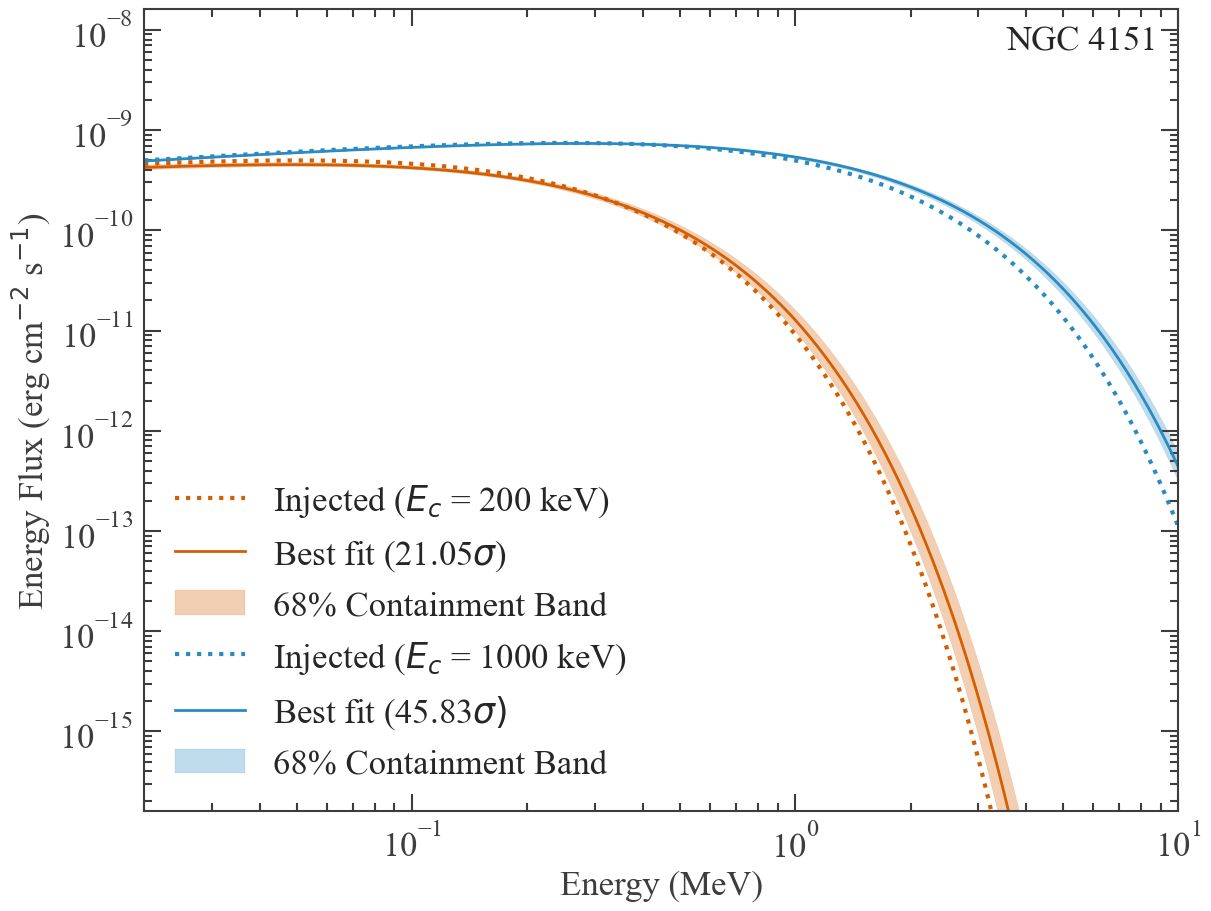

In [24]:
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_inj, color = '#D55E00', ls = ":", lw=3, label = "Injected ($E_c$ = 200 keV)")
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median, color = '#D55E00', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_lo, SED_KEV_TO_ERG * energy * energy *flux_hi, alpha = .3, color = '#D55E00', label = "68% Containment Band")

ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_inj_ec1000, color = '#2A8BC3', ls = ":", lw=3, label = "Injected ($E_c$ = 1000 keV)")
ax.plot(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_median_ec1000, color = '#2A8BC3', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
ax.fill_between(energy * KEV_TO_MEV, SED_KEV_TO_ERG * energy * energy *flux_lo_ec1000, SED_KEV_TO_ERG * energy * energy *flux_hi_ec1000, alpha = .3, color='#2A8BC3', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_ThModel_TH_Fit_200_1000_24Months.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-7 * SED_KEV_TO_ERG, 10 * SED_KEV_TO_ERG)

ax.set_xlim((flux_energy_min_keV) * KEV_TO_MEV, (flux_energy_max_keV) * KEV_TO_MEV)

# ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 5, 10]))
# ax.xaxis.set_major_formatter(
#     mticker.FixedFormatter(["0.1", "5", "10"])
# )

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

## Thermal SED (COSI and BAT)

This extracts bin-by-bin SED points from the thermal fit. The COSI helper keeps the existing measured-energy-bin workflow, and the X-ray helpers repeat the same one-free-normalization method over the requested instrument channels. Both cutoff cases use the same five-bin NuSTAR configuration, while BAT keeps every native channel available in the original 60-200 keV selection. BAT points can be computed for the SED plot without adding BAT to the joint likelihood. Since plot-only BAT is not part of the global likelihood, use `bat_sed_effective_area_scale` and `bat_sed_effective_area_scale_ec1000` to control the fixed BAT SED-only effective-area scale. In every bin the photon index is frozen to the global-fit value; `xc` is also frozen by default because a single band does not constrain the cutoff reliably. The effective-area correction is fixed to the joint-fit value, when available, so the per-bin fit is driven by `K`, matching the COSI nuisance-parameter treatment used below.


In [25]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
def _get_single_source_name(model):
    source_names = [
        name
        for name, child in getattr(model, '_children', {}).items()
        if hasattr(child, 'spectrum')
    ]

    if len(source_names) != 1:
        raise ValueError(f'Expected one source in optimized model, found {source_names}.')

    return source_names[0]


def _get_cutoff_powerlaw_shape(global_results, source_name=None):
    optimized_model = global_results.optimized_model
    if source_name is None:
        source_name = _get_single_source_name(optimized_model)

    return optimized_model[source_name].spectrum.main.Cutoff_powerlaw, source_name


def build_thermal_sed_model(global_results, freeze_cutoff=True, source_name=None):
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)

    spectrum = Cutoff_powerlaw()
    spectrum.K.value = best_fit_shape.K.value
    spectrum.piv.value = best_fit_shape.piv.value
    spectrum.xc.value = best_fit_shape.xc.value
    spectrum.index.value = best_fit_shape.index.value

    spectrum.K.unit = best_fit_shape.K.unit
    spectrum.piv.unit = best_fit_shape.piv.unit
    spectrum.xc.unit = best_fit_shape.xc.unit

    spectrum.K.min_value = max(best_fit_shape.K.value * 1e-3, 1e-12)
    spectrum.K.max_value = best_fit_shape.K.value * 1e3
    spectrum.index.fix = True
    spectrum.xc.fix = freeze_cutoff

    source = PointSource(source_name, l=l, b=b, spectral_shape=spectrum)
    return Model(source)


def _hist_sum(hist):
    contents = hist.contents
    if hasattr(contents, 'todense'):
        contents = contents.todense()
    if hasattr(contents, 'value'):
        contents = contents.value
    return float(np.asarray(contents).sum())


def _integrate_energy_flux(shape, e_min, e_max, n_points=256):
    energy_grid = np.geomspace(e_min, e_max, n_points)
    photon_flux = np.asarray([float(shape.evaluate_at(energy)) for energy in energy_grid])
    trapezoid = getattr(np, 'trapezoid', None)
    if trapezoid is None:
        trapezoid = np.trapz
    return float(trapezoid(energy_grid * photon_flux, energy_grid))


def _extract_profile_error(errors, suffix):
    if hasattr(errors, 'index'):
        for parameter_path in errors.index:
            if str(parameter_path).endswith(suffix):
                row = errors.loc[parameter_path]
                return float(row['negative_error']), float(row['positive_error'])
        return None

    for parameter_path, interval in errors.items():
        if str(parameter_path).endswith(suffix):
            return interval
    return None


def _get_global_background_scale(global_results, default=1.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    for parameter_path in results_frame.index:
        if str(parameter_path).startswith('background_'):
            return float(results_frame.loc[parameter_path, 'value'])

    return float(default)


def _run_joint_likelihood_fit(joint_likelihood):
    fit_status = 'covariance'
    try:
        joint_likelihood.fit(quiet=True)
    except Exception as exc:
        fit_status = f'no-covariance fallback ({type(exc).__name__})'
        joint_likelihood.fit(quiet=True, compute_covariance=False)
    return fit_status


def _get_joint_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()

    if '-log(likelihood)' in statistic_frame.columns:
        statistic_column = statistic_frame['-log(likelihood)']
    else:
        numeric_frame = statistic_frame.select_dtypes(include=[np.number])
        if numeric_frame.empty:
            raise ValueError(f'No numeric statistic columns found in {list(statistic_frame.columns)}.')
        statistic_column = numeric_frame.iloc[:, 0]

    if 'total' in statistic_column.index:
        return float(statistic_column.loc['total'])

    return float(statistic_column.sum())


def _ts_to_sigma(ts_value):
    if not np.isfinite(ts_value) or ts_value <= 0:
        return 0.0

    return float(np.sqrt(ts_value))


def _build_null_sed_model(
    global_results,
    source_name,
    freeze_cutoff=True,
    null_k_value=1e-30,
):
    null_model = build_thermal_sed_model(
        global_results,
        freeze_cutoff=freeze_cutoff,
        source_name=source_name,
    )
    null_shape = null_model[source_name].spectrum.main.Cutoff_powerlaw
    null_k_value = max(float(null_k_value), np.finfo(float).tiny)
    null_k_min = max(null_k_value * 0.1, np.finfo(float).tiny)
    null_shape.K.min_value = min(float(null_shape.K.min_value or null_k_min), null_k_min)
    null_shape.K.value = null_k_value
    null_shape.K.fix = True

    return null_model


def _make_minuit_with_ftol(minuit_ftol):
    if minuit_ftol is None:
        return None

    minuit = LocalMinimization('minuit')
    minuit.setup(ftol=float(minuit_ftol))

    return minuit


def _hits_lower_bound(value, lower_bound):
    if lower_bound is None or not np.isfinite(lower_bound):
        return False

    atol = max(1e-18, abs(float(lower_bound)) * 1e-6)
    return bool(np.isclose(float(value), float(lower_bound), rtol=1e-3, atol=atol))


def _interpolate_profile_crossing(x1, y1, x2, y2, target):
    if np.isclose(y1, y2):
        return float(0.5 * (x1 + x2))

    fraction = float((target - y1) / (y2 - y1))
    fraction = float(np.clip(fraction, 0.0, 1.0))

    if x1 > 0 and x2 > 0:
        return float(np.exp(np.log(x1) + fraction * (np.log(x2) - np.log(x1))))

    return float(x1 + fraction * (x2 - x1))


def _find_profile_crossing(x_values, delta_ts, threshold, side):
    if len(x_values) == 0:
        return None

    minimum_index = int(np.nanargmin(delta_ts))

    if side == 'left':
        for index in range(minimum_index - 1, -1, -1):
            y1 = float(delta_ts[index])
            y2 = float(delta_ts[index + 1])
            if np.isnan(y1) or np.isnan(y2):
                continue
            if np.isclose(y1, threshold):
                return float(x_values[index])
            if (y1 - threshold) * (y2 - threshold) <= 0:
                return _interpolate_profile_crossing(
                    float(x_values[index]),
                    y1,
                    float(x_values[index + 1]),
                    y2,
                    threshold,
                )
        return None

    for index in range(minimum_index, len(x_values) - 1):
        y1 = float(delta_ts[index])
        y2 = float(delta_ts[index + 1])
        if np.isnan(y1) or np.isnan(y2):
            continue
        if np.isclose(y2, threshold):
            return float(x_values[index + 1])
        if (y1 - threshold) * (y2 - threshold) <= 0:
            return _interpolate_profile_crossing(
                float(x_values[index]),
                y1,
                float(x_values[index + 1]),
                y2,
                threshold,
            )

    return None


def _manual_k_profile_interval(
    joint_likelihood,
    parameter_path,
    center_value,
    lower_bound,
    upper_bound,
    n_steps=61,
    target_delta_ts=1.0,
    max_expansions=12,
    scan_expand_factor=1e2,
):
    if center_value <= 0:
        raise ValueError('Manual K profiling requires a positive best-fit normalization.')

    tiny_positive = float(np.finfo(float).tiny)
    scan_min = max(float(lower_bound), tiny_positive)
    scan_max = float(upper_bound) if np.isfinite(upper_bound) else float(center_value) * 1e6

    if not np.isfinite(scan_max) or scan_max <= scan_min:
        raise ValueError('Invalid K scan bounds for manual profiling.')

    import matplotlib.pyplot as plt

    left_crossing = None
    right_crossing = None

    for _ in range(max_expansions + 1):
        x_values, _, profile_values, profile_figure = joint_likelihood.get_contours(
            parameter_path,
            param_1_minimum=float(scan_min),
            param_1_maximum=float(scan_max),
            param_1_n_steps=int(n_steps),
            progress=False,
            log=(True,),
        )
        plt.close(profile_figure)

        x_values = np.asarray(x_values, dtype=float)
        profile_values = np.asarray(profile_values, dtype=float)
        delta_ts = 2.0 * (profile_values - np.nanmin(profile_values))
        minimum_index = int(np.nanargmin(delta_ts))

        left_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'left')
        right_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'right')

        if left_crossing is not None and right_crossing is not None:
            status = f'manual K profile ok ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
            return float(left_crossing), float(right_crossing), status

        expanded = False

        if left_crossing is None and minimum_index > 0 and delta_ts[0] < target_delta_ts and scan_min > lower_bound:
            new_scan_min = max(float(lower_bound), float(scan_min) / scan_expand_factor)
            if new_scan_min < scan_min:
                scan_min = new_scan_min
                expanded = True

        if right_crossing is None and minimum_index < (len(x_values) - 1) and delta_ts[-1] < target_delta_ts and scan_max < upper_bound:
            new_scan_max = min(float(upper_bound), float(scan_max) * scan_expand_factor)
            if new_scan_max > scan_max:
                scan_max = new_scan_max
                expanded = True

        if not expanded:
            break

    status = f'manual K profile incomplete ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
    return left_crossing, right_crossing, status


def fit_thermal_cosi_sed(
    global_results,
    data_hist,
    bkg_hist,
    dr_path,
    sc_orientation,
    n_sed_bins=5,
    freeze_cutoff=True,
    freeze_background=False,
    background_scale_value=None,
    minuit_ftol=None,
    error_estimation='minos_then_manual',
    manual_k_profile_points=61,
    manual_one_sided_mode='upper_limit',
    relax_k_lower_bound=True,
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e2,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    em_edges = data_hist.axes['Em'].edges.to_value(u.keV)
    native_em_bins = np.flatnonzero(
        (em_edges[:-1] >= energy_min_keV) & (em_edges[1:] <= energy_max_keV)
    )

    if len(native_em_bins) == 0:
        raise ValueError(
            f'No native Em bins are fully contained in {energy_min_keV}-{energy_max_keV} keV.'
        )

    def _split_last_group_remainder(arr, n_groups):
        arr = np.asarray(arr)
        if len(arr) < n_groups:
            raise ValueError(f"Need at least {n_groups} native bins, got {len(arr)}.")

        sizes = [1] * (n_groups - 1)
        sizes.append(len(arr) - (n_groups - 1))

        groups = []
        start = 0
        for size in sizes:
            groups.append(arr[start:start + size])
            start += size

        return groups

    grouped_bins = _split_last_group_remainder(native_em_bins, n_sed_bins)

    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_background_scale = _get_global_background_scale(global_results, default=1.0)

    if background_scale_value is not None:
        background_scale_value = float(background_scale_value)

    for sed_bin_index, group in enumerate(grouped_bins, start=1):
        em_slice = slice(int(group[0]), int(group[-1]) + 1)
        e_min = float(em_edges[group[0]])
        e_max = float(em_edges[group[-1] + 1])
        e_ref = float(np.sqrt(e_min * e_max))
        data_counts = _hist_sum(data_hist.slice[{'Em': em_slice}])
        background_counts = _hist_sum(bkg_hist.slice[{'Em': em_slice}])

        dataset_name = f'cosi_sed_bin_{sed_bin_index}'

        bin_cosi = EnergyRangeCOSIPlugin(
            name=dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(dataset_name),
            earth_occ=True,
        )

        background_parameter = bin_cosi.nuisance_parameters[f'background_{dataset_name}']

        if freeze_background:
            if background_scale_value is None:
                background_parameter.value = global_background_scale
            else:
                background_parameter.value = background_scale_value
            background_parameter.fix = True
        else:
            background_parameter.fix = False
            if background_scale_value is not None:
                background_parameter.value = background_scale_value

        bin_model = build_thermal_sed_model(global_results, freeze_cutoff=freeze_cutoff, source_name=source_name)
        bin_like = JointLikelihood(bin_model, DataList(bin_cosi), verbose=False)

        bin_minuit = _make_minuit_with_ftol(minuit_ftol)
        if bin_minuit is not None:
            bin_like.set_minimizer(bin_minuit)

        # threeML can reject every covariance sample in weak bins and then crash while building the summary table.
        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        if relax_k_lower_bound and _hits_lower_bound(k_value, k_min):
            relaxed_k_min = max(k_min * 1e-2, 1e-18)
            if relaxed_k_min < k_min:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.min_value = relaxed_k_min
                retry_status = _run_joint_likelihood_fit(bin_like)
                fit_status = f'{fit_status}; relaxed K min to {relaxed_k_min:.3e}; retry={retry_status}'
                bin_results = bin_like.results
                fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
                k_value = float(fit_shape.K.value)
                k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
                k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
                k_lower_bound_relaxed = True

        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_dataset_name = f'{dataset_name}_null'
        null_cosi = EnergyRangeCOSIPlugin(
            name=null_dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(null_dataset_name),
            earth_occ=True,
        )

        null_background_parameter = null_cosi.nuisance_parameters[f'background_{null_dataset_name}']
        if freeze_background:
            if background_scale_value is None:
                null_background_parameter.value = global_background_scale
            else:
                null_background_parameter.value = background_scale_value
            null_background_parameter.fix = True
        else:
            null_background_parameter.fix = False
            if background_scale_value is not None:
                null_background_parameter.value = background_scale_value
            else:
                null_background_parameter.value = float(background_parameter.value)

        null_model = _build_null_sed_model(
            global_results,
            source_name=source_name,
            freeze_cutoff=freeze_cutoff,
        )
        null_like = JointLikelihood(null_model, DataList(null_cosi), verbose=False)

        null_minuit = _make_minuit_with_ftol(minuit_ftol)
        if null_minuit is not None:
            null_like.set_minimizer(null_minuit)

        null_fit_status = _run_joint_likelihood_fit(null_like)
        joint_null_statistic = _get_joint_likelihood_statistic(null_like)
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, float(ts_value_raw))
        sigma = _ts_to_sigma(ts_value)

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, '.K')
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, '.K')
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value = profile_k_max
                k_max = float(bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value)

            k_path = f'{source_name}.spectrum.main.Cutoff_powerlaw.K'
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        scale_lo = k_lo / k_value if k_value > 0 else 1.0
        scale_hi = k_hi / k_value if k_value > 0 else 1.0
        integrated_flux = _integrate_energy_flux(fit_shape, e_min, e_max)
        sed_flux = float(e_ref**2 * fit_shape.evaluate_at(e_ref))
        background_scale = float(bin_cosi.nuisance_parameters[f'background_{dataset_name}'].value)
        background_is_fixed = bool(background_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )

        sed_rows.append(
            {
                'bin_index': sed_bin_index,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_erg_cm2_s': integrated_flux,
                'bin_energy_flux_lo_erg_cm2_s': integrated_flux * scale_lo,
                'bin_energy_flux_hi_erg_cm2_s': integrated_flux * scale_hi,
                'sed_erg_cm2_s': sed_flux,
                'sed_lo_erg_cm2_s': sed_flux * scale_lo,
                'sed_hi_erg_cm2_s': sed_flux * scale_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'background_scale': background_scale,
                'background_scale_reference': (
                    global_background_scale if background_scale_value is None else background_scale_value
                ),
                'background_requested_fixed': freeze_background,
                'background_scale_fixed': background_is_fixed,
                'background_released_for_retry': False,
                'data_counts': data_counts,
                'background_counts': background_counts,
                'excess_counts': data_counts - background_counts,
                'joint_statistic': joint_statistic,
                'joint_null_statistic': joint_null_statistic,
                'ts_value_raw': ts_value_raw,
                'ts_value': ts_value,
                'sigma': sigma,
                'null_fit_status': null_fit_status,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    sed_df = pd.DataFrame(sed_rows)
    energy_flux_columns = [
        column for column in sed_df.columns
        if column.endswith("_erg_cm2_s")
    ]
    sed_df[energy_flux_columns] *= SED_KEV_TO_ERG
    return sed_df


def _get_effective_area_scale(global_results, plugin_name='BAT', default=1.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    candidates = [f'cons_{plugin_name}']
    for parameter_path in results_frame.index:
        parameter_name = str(parameter_path).split('.')[-1]
        if parameter_name in candidates or parameter_name.startswith(f'cons_{plugin_name}'):
            return float(results_frame.loc[parameter_path, 'value'])

    return float(default)


def _make_ogip_plugin(dataset_name, observation_path, response_path, background_path=None, arf_file=None):
    ogip_kwargs = {
        'observation': observation_path,
        'response': response_path,
        'verbose': False,
    }

    if background_path is not None:
        ogip_kwargs['background'] = background_path

    if arf_file is not None:
        ogip_kwargs['arf_file'] = arf_file

    return OGIPLike(dataset_name, **ogip_kwargs)


def _get_ogip_active_channel_bins(observation_path, response_path, active_range, background_path=None, arf_file=None, instrument='OGIP'):
    probe = _make_ogip_plugin(
        '__ogip_sed_probe__',
        observation_path=observation_path,
        response_path=response_path,
        background_path=background_path,
        arf_file=arf_file,
    )
    probe.set_active_measurements(active_range)

    active_channel_indices = np.flatnonzero(np.asarray(probe.mask, dtype=bool))
    e_min_active, e_max_active = probe.energy_boundaries

    if len(active_channel_indices) == 0:
        raise ValueError(f'No {instrument} channels selected by active range {active_range!r}.')

    return [
        {
            'channel_index': int(channel_index),
            'channel_number': int(channel_index + 1),
            'e_min_keV': float(e_min),
            'e_max_keV': float(e_max),
        }
        for channel_index, e_min, e_max in zip(active_channel_indices, e_min_active, e_max_active)
    ]


def _group_ogip_channel_bins(ogip_bins, n_sed_bins=None):
    if n_sed_bins is None:
        return [[ogip_bin] for ogip_bin in ogip_bins]

    n_sed_bins = max(1, min(int(n_sed_bins), len(ogip_bins)))

    return [list(group) for group in np.array_split(np.asarray(ogip_bins, dtype=object), n_sed_bins)]


def _summarize_ogip_bin_group(ogip_bin_group):
    return {
        'channel_index': [int(ogip_bin['channel_index']) for ogip_bin in ogip_bin_group],
        'channel_number': '-'.join(str(int(ogip_bin['channel_number'])) for ogip_bin in ogip_bin_group),
        'e_min_keV': float(ogip_bin_group[0]['e_min_keV']),
        'e_max_keV': float(ogip_bin_group[-1]['e_max_keV']),
    }


def _select_single_ogip_channel(plugin, channel_index):
    channel_mask = np.zeros_like(np.asarray(plugin.mask, dtype=bool))
    channel_mask[np.asarray(channel_index, dtype=int)] = True
    plugin._mask = channel_mask
    plugin._apply_mask_to_original_vectors()


def fit_thermal_bat_sed(
    global_results,
    observation_path,
    response_path,
    background_path=None,
    arf_file=None,
    active_range='40-200',
    instrument='BAT',
    plugin_name='BAT',
    dataset_prefix='bat',
    freeze_cutoff=True,
    freeze_effective_area=True,
    effective_area_value=None,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    scan_expand_factor=1e3,
    n_sed_bins=None,
    sed_energy_min_keV=None,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    ogip_bins = _get_ogip_active_channel_bins(
        observation_path,
        response_path,
        active_range,
        background_path=background_path,
        arf_file=arf_file,
        instrument=instrument,
    )

    if sed_energy_min_keV is not None:
        ogip_bins = [ogip_bin for ogip_bin in ogip_bins if ogip_bin['e_min_keV'] >= sed_energy_min_keV]
        if not ogip_bins:
            raise ValueError(f'No {instrument} SED channels start at or above {sed_energy_min_keV} keV.')

    ogip_bin_groups = [_summarize_ogip_bin_group(group) for group in _group_ogip_channel_bins(ogip_bins, n_sed_bins=n_sed_bins)]
    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_effective_area_scale = _get_effective_area_scale(global_results, plugin_name=plugin_name, default=1.0)

    if effective_area_value is not None:
        effective_area_value = float(effective_area_value)

    for sed_bin_index, ogip_bin in enumerate(ogip_bin_groups, start=1):
        e_min = ogip_bin['e_min_keV']
        e_max = ogip_bin['e_max_keV']
        e_ref = float(np.sqrt(e_min * e_max))
        channel_indices = ogip_bin['channel_index']
        channel_number = ogip_bin['channel_number']
        dataset_name = f'{dataset_prefix}_sed_bin_{sed_bin_index}'

        bin_bat = _make_ogip_plugin(
            dataset_name,
            observation_path=observation_path,
            response_path=response_path,
            background_path=background_path,
            arf_file=arf_file,
        )
        bin_bat.set_active_measurements(active_range)
        _select_single_ogip_channel(bin_bat, channel_indices)
        bin_bat.use_effective_area_correction(0.2, 1.8)

        area_parameter = bin_bat.nuisance_parameters[f'cons_{dataset_name}']
        area_reference = global_effective_area_scale if effective_area_value is None else effective_area_value

        if freeze_effective_area:
            bin_bat.fix_effective_area_correction(area_reference)
        else:
            area_parameter.value = area_reference
            area_parameter.fix = False

        bin_model = build_thermal_sed_model(global_results, freeze_cutoff=freeze_cutoff, source_name=source_name)
        bin_like = JointLikelihood(bin_model, DataList(bin_bat), verbose=False)

        bin_minuit = _make_minuit_with_ftol(minuit_ftol)
        if bin_minuit is not None:
            bin_like.set_minimizer(bin_minuit)

        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_dataset_name = f'{dataset_name}_null'
        null_bat = _make_ogip_plugin(
            null_dataset_name,
            observation_path=observation_path,
            response_path=response_path,
            background_path=background_path,
            arf_file=arf_file,
        )
        null_bat.set_active_measurements(active_range)
        _select_single_ogip_channel(null_bat, channel_indices)
        null_bat.use_effective_area_correction(0.2, 1.8)

        null_area_parameter = null_bat.nuisance_parameters[f'cons_{null_dataset_name}']
        if freeze_effective_area:
            null_bat.fix_effective_area_correction(area_reference)
        else:
            null_area_parameter.value = effective_area_value if effective_area_value is not None else float(area_parameter.value)
            null_area_parameter.fix = False

        null_model = _build_null_sed_model(
            global_results,
            source_name=source_name,
            freeze_cutoff=freeze_cutoff,
        )
        null_like = JointLikelihood(null_model, DataList(null_bat), verbose=False)

        null_minuit = _make_minuit_with_ftol(minuit_ftol)
        if null_minuit is not None:
            null_like.set_minimizer(null_minuit)

        null_fit_status = _run_joint_likelihood_fit(null_like)
        joint_null_statistic = _get_joint_likelihood_statistic(null_like)
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, float(ts_value_raw))
        sigma = _ts_to_sigma(ts_value)

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, '.K')
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, '.K')
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value = profile_k_max
                k_max = float(bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value)

            k_path = f'{source_name}.spectrum.main.Cutoff_powerlaw.K'
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        scale_lo = k_lo / k_value if k_value > 0 else 1.0
        scale_hi = k_hi / k_value if k_value > 0 else 1.0
        integrated_flux = _integrate_energy_flux(fit_shape, e_min, e_max)
        sed_flux = float(e_ref**2 * fit_shape.evaluate_at(e_ref))
        effective_area_scale = float(area_parameter.value)
        effective_area_is_fixed = bool(area_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )
        observed_counts = float(np.asarray(bin_bat._current_observed_counts).sum())
        current_background_counts = getattr(bin_bat, '_current_background_counts', None)
        if current_background_counts is None:
            background_counts = 0.0
        else:
            background_counts = float(np.asarray(current_background_counts).sum())

        sed_rows.append(
            {
                'instrument': instrument,
                'detector': plugin_name,
                'bin_index': sed_bin_index,
                'channel_index': channel_indices,
                'channel_number': channel_number,
                'active_range': active_range,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_erg_cm2_s': integrated_flux,
                'bin_energy_flux_lo_erg_cm2_s': integrated_flux * scale_lo,
                'bin_energy_flux_hi_erg_cm2_s': integrated_flux * scale_hi,
                'sed_erg_cm2_s': sed_flux,
                'sed_lo_erg_cm2_s': sed_flux * scale_lo,
                'sed_hi_erg_cm2_s': sed_flux * scale_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'effective_area_scale': effective_area_scale,
                'effective_area_scale_reference': area_reference,
                'effective_area_requested_fixed': freeze_effective_area,
                'effective_area_scale_fixed': effective_area_is_fixed,
                'data_counts': observed_counts,
                'background_counts': background_counts,
                'excess_counts': observed_counts - background_counts,
                'joint_statistic': joint_statistic,
                'joint_null_statistic': joint_null_statistic,
                'ts_value_raw': ts_value_raw,
                'ts_value': ts_value,
                'sigma': sigma,
                'null_fit_status': null_fit_status,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    sed_df = pd.DataFrame(sed_rows)
    energy_flux_columns = [
        column for column in sed_df.columns
        if column.endswith("_erg_cm2_s")
    ]
    sed_df[energy_flux_columns] *= SED_KEV_TO_ERG
    return sed_df


def fit_thermal_nustar_sed(
    global_results,
    fpma_observation_path,
    fpma_background_path,
    fpma_response_path,
    fpma_arf_file,
    fpmb_observation_path,
    fpmb_background_path,
    fpmb_response_path,
    fpmb_arf_file,
    active_range='30-79',
    n_sed_bins=5,
    sed_energy_min_keV=None,
    **sed_kwargs,
):
    sed_frames = []
    detector_specs = [
        ('nustar_fpma', fpma_observation_path, fpma_background_path, fpma_response_path, fpma_arf_file),
        ('nustar_fpmb', fpmb_observation_path, fpmb_background_path, fpmb_response_path, fpmb_arf_file),
    ]

    for detector_name, observation_path, background_path, response_path, arf_file in detector_specs:
        sed_frames.append(
            fit_thermal_bat_sed(
                global_results=global_results,
                observation_path=observation_path,
                background_path=background_path,
                response_path=response_path,
                arf_file=arf_file,
                active_range=active_range,
                instrument='NuSTAR',
                plugin_name=detector_name,
                dataset_prefix=detector_name,
                n_sed_bins=n_sed_bins,
                sed_energy_min_keV=sed_energy_min_keV,
                **sed_kwargs,
            )
        )

    combined_sed = pd.concat(sed_frames, ignore_index=True)
    if n_sed_bins is None:
        return combined_sed

    combined_rows = []
    for _, bin_rows in combined_sed.groupby('bin_index', sort=True):
        row = bin_rows.iloc[0].copy()
        row['detector'] = 'nustar_fpma+nustar_fpmb'
        row['channel_index'] = list(bin_rows['channel_index'])
        row['channel_number'] = str(row['channel_number'])

        for column in ('data_counts', 'background_counts', 'excess_counts'):
            row[column] = float(bin_rows[column].sum())

        for column in ('joint_statistic', 'joint_null_statistic', 'ts_value_raw', 'ts_value'):
            row[column] = float(bin_rows[column].sum())

        row['sigma'] = _ts_to_sigma(row['ts_value'])

        for column in (
            'bin_energy_flux_erg_cm2_s',
            'bin_energy_flux_lo_erg_cm2_s',
            'bin_energy_flux_hi_erg_cm2_s',
            'sed_erg_cm2_s',
            'sed_lo_erg_cm2_s',
            'sed_hi_erg_cm2_s',
            'source_K',
            'source_K_lo',
            'source_K_hi',
            'source_K_over_global',
            'effective_area_scale',
            'effective_area_scale_reference',
        ):
            row[column] = float(bin_rows[column].mean())

        row['effective_area_scale_fixed'] = bool(bin_rows['effective_area_scale_fixed'].all())
        row['is_upper_limit'] = bool(bin_rows['is_upper_limit'].all())
        combined_rows.append(row)

    return pd.DataFrame(combined_rows).reset_index(drop=True)



In [26]:
n_thermal_sed_bins = 8

# # Manual Scan
# thermal_cosi_sed_df = fit_thermal_cosi_sed(
#     global_results=results_sed,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df = fit_thermal_cosi_sed(
    global_results=results_sed,
    data_hist=data_sed_hist,
    bkg_hist=bkg_sed_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=False,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e6,
)


display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "excess_counts",
            "joint_statistic",
            "joint_null_statistic",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

14:29:45 INFO      set the minimizer to minuit                                             ]8;id=770007;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=368691;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=190398;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=800414;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:29:53 INFO      set the minimizer to minuit                                             ]8;id=704869;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=620299;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=791462;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=758371;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:30:01 INFO      set the minimizer to minuit                                             ]8;id=567540;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=800614;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

         INFO      set the minimizer to minuit                                             ]8;id=608069;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=5011;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:31:46 INFO      set the minimizer to minuit                                             ]8;id=217124;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=872554;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=671034;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=29531;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s
0,1,100.000,158.489,125.892414,9.812633e-11,6.246838e-11,1.368037e-10
1,2,158.489,251.189,199.526172,1.428689e-10,1.227240e-10,1.630415e-10
2,3,251.189,398.107,316.227923,1.158941e-10,9.806918e-11,1.339105e-10
3,4,398.107,630.957,501.186989,1.072295e-11,4.695717e-14,3.124743e-11
4,5,630.957,1000.000,794.328018,4.773438e-11,1.943803e-11,7.608488e-11
5,6,1000.000,1584.890,1258.924144,1.717803e-11,2.348729e-15,6.219673e-11
6,7,1584.890,2511.890,1995.261723,8.036246e-16,1.329557e-16,4.493869e-11
7,8,2511.890,10000.000,5011.875896,1.571862e-12,1.571907e-18,1.571907e-12


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,6.460032e-06,4.112533e-06,0.000009,0.542537,25.626384,25.569434,False,False,False,3385652.0,3371214.0,14438.0,-1.551691e+07,-1.551679e+07,229.396127,15.145829,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
1,2,1.180467e-05,1.014018e-05,0.000013,0.991400,25.570908,25.569434,False,False,False,6806597.0,6783193.0,23404.0,-3.499737e+07,-3.499734e+07,50.370669,7.097230,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
2,3,1.449860e-05,1.226866e-05,0.000017,1.217646,25.557254,25.569434,False,False,False,5228700.0,5215451.0,13249.0,-2.497700e+07,-2.497693e+07,154.905648,12.446110,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
3,4,2.719052e-06,1.190708e-08,0.000008,0.228356,25.587204,25.569434,False,False,False,3543047.0,3540103.0,2944.0,-1.517171e+07,-1.517171e+07,0.272641,0.522150,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
4,5,3.844966e-05,1.565718e-05,0.000061,3.229144,25.569352,25.569434,False,False,False,2339388.0,2337742.0,1646.0,-9.024023e+06,-9.024021e+06,2.847886,1.687568,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
5,6,8.708545e-05,1.190708e-08,0.000315,7.313757,25.539389,25.569434,False,False,False,1869466.0,1871494.0,-2028.0,-6.808261e+06,-6.808261e+06,0.146966,0.383362,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
6,7,7.196996e-08,1.190708e-08,0.004025,0.006044,25.538510,25.569434,False,False,False,1266096.0,1267750.0,-1654.0,-4.184101e+06,-4.184101e+06,0.000000,0.000000,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
7,8,1.190674e-02,1.190708e-08,0.011907,999.971617,25.584874,25.569434,False,False,False,684440.0,684087.0,353.0,-1.570728e+06,-1.570728e+06,0.009785,0.098919,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False


In [27]:
n_thermal_sed_bins = 10

# # Manual Scan
# thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
#     global_results=results_sed_ec1000,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     manual_one_sided_mode='lower_bound_interval',
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
    global_results=results_sed_ec1000,
    data_hist=data_sed_ec1000_hist,
    bkg_hist=bkg_sed_ec1000_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=81,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=100,
    energy_max_keV=10000,
    scan_expand_factor=1e3,
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_erg_cm2_s",
            "bin_energy_flux_lo_erg_cm2_s",
            "bin_energy_flux_hi_erg_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df_ec1000[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "excess_counts",
            "joint_statistic",
            "joint_null_statistic",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "manual_one_sided_mode",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

14:31:55 INFO      set the minimizer to minuit                                             ]8;id=363579;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=616443;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=303956;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=396010;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:32:03 INFO      set the minimizer to minuit                                             ]8;id=764975;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=593801;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=546126;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=176548;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:32:11 INFO      set the minimizer to minuit                                             ]8;id=999659;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=924137;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

         INFO      set the minimizer to minuit                                             ]8;id=400336;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=776066;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

14:34:53 INFO      set the minimizer to minuit                                             ]8;id=644981;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=372342;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=486492;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=113748;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s
0,1,100.000,158.489,125.892414,3.023323e-10,2.818726e-10,3.228387e-10
1,2,158.489,251.189,199.526172,3.419386e-10,3.299372e-10,3.539467e-10
2,3,251.189,398.107,316.227923,3.473156e-10,3.353839e-10,3.592575e-10
3,4,398.107,630.957,501.186989,3.126462e-10,2.968584e-10,3.284874e-10
4,5,630.957,1000.000,794.328018,2.499225e-10,2.263005e-10,2.735784e-10
5,6,1000.000,1584.890,1258.924144,2.132710e-10,1.741468e-10,2.526147e-10
6,7,1584.890,2511.890,1995.261723,1.577978e-10,8.916757e-11,2.265571e-10
7,8,2511.890,3981.070,3162.279229,5.310249e-11,1.655150e-11,1.167412e-10
8,9,3981.070,6309.570,5011.869895,1.328624e-14,1.314685e-14,3.641057e-11
9,10,6309.570,10000.000,7943.280179,6.571774e-15,1.446220e-15,6.217260e-11


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,manual_one_sided_mode,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,1.273843e-05,1.187638e-05,0.000014,0.946787,25.585425,25.585425,True,True,False,3397766.0,3371214.0,26552.0,-1.558463e+07,-1.558441e+07,444.663871,21.087055,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
1,2,1.376185e-05,1.327883e-05,0.000014,1.022853,25.585425,25.585425,True,True,False,6848686.0,6783193.0,65493.0,-3.525669e+07,-3.525628e+07,820.986691,28.652865,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
2,3,1.385513e-05,1.337915e-05,0.000014,1.029786,25.585425,25.585425,True,True,False,5270911.0,5215451.0,55460.0,-2.522336e+07,-2.522282e+07,1086.308483,32.959194,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
3,4,1.310489e-05,1.244313e-05,0.000014,0.974025,25.585425,25.585425,True,True,False,3566227.0,3540103.0,26124.0,-1.529238e+07,-1.529195e+07,848.512502,29.129238,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
4,5,1.206732e-05,1.092675e-05,0.000013,0.896907,25.585425,25.585425,True,True,False,2350984.0,2337742.0,13242.0,-9.078446e+06,-9.078390e+06,113.319879,10.645181,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
5,6,1.370448e-05,1.119042e-05,0.000016,1.018590,25.585425,25.585425,True,True,False,1876552.0,1871494.0,5058.0,-6.839668e+06,-6.839597e+06,142.543160,11.939144,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
6,7,1.690727e-05,9.553873e-06,0.000024,1.256637,25.585425,25.585425,True,True,False,1268360.0,1267750.0,610.0,-4.192430e+06,-4.192427e+06,5.304487,2.303147,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
7,8,1.345437e-05,4.193590e-06,0.000030,1.000000,25.585425,25.585425,True,True,False,546561.0,547020.0,-459.0,-1.396274e+06,-1.396218e+06,113.828668,10.669052,covariance,covariance,"manual K profile ok (81 points, 1.345e-08-1.34...",manual profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
8,9,1.359702e-08,1.345437e-08,0.000037,0.001011,25.585425,25.585425,True,True,False,124698.0,124966.0,-268.0,-1.721947e+05,-1.721947e+05,0.000000,0.000000,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,True,False
9,10,6.113805e-08,1.345437e-08,0.000578,0.004544,25.585425,25.585425,True,True,False,12138.0,12101.0,37.0,-4.107858e+02,-4.107859e+02,0.000000,0.000000,covariance,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False


In [28]:
SED_DISPLAY_COLUMNS = [
    'instrument',
    'detector',
    'bin_index',
    'channel_number',
    'e_min_keV',
    'e_max_keV',
    'e_ref_keV',
    'bin_energy_flux_erg_cm2_s',
    'bin_energy_flux_lo_erg_cm2_s',
    'bin_energy_flux_hi_erg_cm2_s',
    'sed_erg_cm2_s',
    'sed_lo_erg_cm2_s',
    'sed_hi_erg_cm2_s',
    'source_K',
    'source_K_lo',
    'source_K_hi',
    'source_K_over_global',
    'effective_area_scale',
    'effective_area_scale_reference',
    'effective_area_scale_fixed',
    'data_counts',
    'background_counts',
    'excess_counts',
    'joint_statistic',
    'joint_null_statistic',
    'ts_value',
    'sigma',
    'fit_status',
    'null_fit_status',
    'profile_error_status',
    'error_source',
    'is_upper_limit',
]

# The bin-by-bin BAT fits must use the same effective-area correction as
# the corresponding global joint fit. Otherwise K absorbs the area-scale
# mismatch and shifts every BAT SED point away from the fitted spectrum.
bat_sed_effective_area_scale = _get_effective_area_scale(
    results_sed,
    plugin_name='BAT',
    default=1.0,
)
bat_sed_effective_area_scale_ec1000 = _get_effective_area_scale(
    results_sed_ec1000,
    plugin_name='BAT',
    default=1.0,
)
print(f'BAT effective-area scale (200 keV fit): {bat_sed_effective_area_scale:.6f}')
print(f'BAT effective-area scale (1000 keV fit): {bat_sed_effective_area_scale_ec1000:.6f}')

# bat_sed_effective_area_scale = 0.5
# bat_sed_effective_area_scale_ec1000 = 0.9


if has_bat_fit_200 and all(name in globals() for name in ('bat_pha_ec200', 'bat_rsp_ec200')):
    thermal_bat_sed_df = fit_thermal_bat_sed(
        global_results=results_sed,
        observation_path=bat_pha_ec200,
        response_path=bat_rsp_ec200,
        active_range='40-200',
        freeze_cutoff=True,
        freeze_effective_area=True,
        minuit_ftol=1e-2,
        error_estimation='minos_then_manual',
        manual_k_profile_points=201,
        manual_one_sided_mode='lower_bound_interval',
        scan_expand_factor=1e3,
    )
    display(thermal_bat_sed_df[SED_DISPLAY_COLUMNS])

if all(name in globals() for name in ('bat_pha_ec200', 'bat_rsp_ec200')):
    thermal_bat_sed_df_60_200 = fit_thermal_bat_sed(
        global_results=results_sed,
        observation_path=bat_pha_ec200,
        response_path=bat_rsp_ec200,
        active_range='60-200',
        n_sed_bins=None,  # Keep every native BAT channel in the selected range.
        freeze_cutoff=True,
        freeze_effective_area=True,
        effective_area_value=bat_sed_effective_area_scale,
        minuit_ftol=1e-2,
        error_estimation='minos_then_manual',
        manual_k_profile_points=201,
        manual_one_sided_mode='lower_bound_interval',
        scan_expand_factor=1e3,
    )
    display(thermal_bat_sed_df_60_200[SED_DISPLAY_COLUMNS])

if has_nustar_fit_200:
    thermal_nustar_sed_df = fit_thermal_nustar_sed(
        global_results=results_sed,
        fpma_observation_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.pha',
        fpma_background_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_bk.pha',
        fpma_response_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.rmf',
        fpma_arf_file='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.arf',
        fpmb_observation_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.pha',
        fpmb_background_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_bk.pha',
        fpmb_response_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.rmf',
        fpmb_arf_file='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.arf',
        active_range='20-60',
        n_sed_bins=5,
        freeze_cutoff=True,
        freeze_effective_area=True,
        minuit_ftol=1e-2,
        error_estimation='minos_then_manual',
        manual_k_profile_points=201,
        manual_one_sided_mode='lower_bound_interval',
        scan_expand_factor=1e3,
    )
    display(thermal_nustar_sed_df[SED_DISPLAY_COLUMNS])


BAT effective-area scale (200 keV fit): 0.542501
BAT effective-area scale (1000 keV fit): 0.955159


14:35:03 INFO      Auto-probed noise models:                                                    ]8;id=449993;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=193337;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=886947;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=898824;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=393948;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=149980;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=124897;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=111953;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

...

         INFO      Range 20-60 translates to channels 459-1459                                 ]8;id=239847;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=195975;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      nustar_fpmb_sed_bin_5_null is using effective area correction (between 0.2  ]8;id=256627;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=552327;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\
                  and 1.8)                                                                                         

         INFO      set the minimizer to minuit                                             ]8;id=174586;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=715171;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=891060;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=234237;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,instrument,detector,bin_index,channel_number,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s,sed_erg_cm2_s,sed_lo_erg_cm2_s,sed_hi_erg_cm2_s,source_K,source_K_lo,source_K_hi,source_K_over_global,effective_area_scale,effective_area_scale_reference,effective_area_scale_fixed,data_counts,background_counts,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,is_upper_limit
0,NuSTAR,nustar_fpma+nustar_fpmb,1,460-461-462-463-464-465-466-467-468-469-470-47...,19.959999,28.0,23.640642,1.351906e-10,1.337538e-10,1.366376e-10,3.995884e-10,3.953415e-10,4.038655e-10,0.000011,0.000011,0.000011,0.925268,0.94515,0.94515,True,17647.0,203.0,17444.0,1490.534016,35962.903363,68944.738695,262.573302,covariance,covariance,ok,profile,False
1,NuSTAR,nustar_fpma+nustar_fpmb,2,661-662-663-664-665-666-667-668-669-670-671-67...,28.000000,36.0,31.749016,1.094277e-10,1.074893e-10,1.113864e-10,4.355768e-10,4.278607e-10,4.433731e-10,0.000012,0.000011,0.000012,0.980699,0.94515,0.94515,True,6366.0,170.0,6196.0,1255.575217,13293.626009,24076.101585,155.164756,covariance,covariance,ok,profile,False
2,NuSTAR,nustar_fpma+nustar_fpmb,3,861-862-863-864-865-866-867-868-869-870-871-87...,36.000000,44.0,39.799497,9.248606e-11,9.018969e-11,9.482199e-11,4.610204e-10,4.495735e-10,4.726644e-10,0.000012,0.000012,0.000013,1.024237,0.94515,0.94515,True,3216.0,88.0,3128.0,1088.796920,7108.389195,12039.184549,109.723218,covariance,covariance,ok,profile,False
3,NuSTAR,nustar_fpma+nustar_fpmb,4,1061-1062-1063-1064-1065-1066-1067-1068-1069-1...,44.000000,52.0,47.833043,7.786179e-11,7.521507e-11,8.056776e-11,4.662026e-10,4.503551e-10,4.824048e-10,0.000012,0.000012,0.000013,1.031356,0.94515,0.94515,True,1719.0,84.0,1635.0,944.961468,4012.854935,6135.786933,78.331264,covariance,covariance,ok,profile,False
4,NuSTAR,nustar_fpma+nustar_fpmb,5,1261-1262-1263-1264-1265-1266-1267-1268-1269-1...,52.000000,60.0,55.856960,6.178660e-11,5.884174e-11,6.482679e-11,4.318608e-10,4.112775e-10,4.531104e-10,0.000011,0.000011,0.000012,0.957261,0.94515,0.94515,True,870.0,67.0,803.0,745.336060,2179.986434,2869.300747,53.565854,covariance,covariance,ok,profile,False


In [29]:
if has_bat_fit_1000 and all(name in globals() for name in ('bat_pha_ec1000', 'bat_rsp_ec1000')):
    thermal_bat_sed_df_ec1000 = fit_thermal_bat_sed(
        global_results=results_sed_ec1000,
        observation_path=bat_pha_ec1000,
        response_path=bat_rsp_ec1000,
        active_range='40-200',
        freeze_cutoff=True,
        freeze_effective_area=True,
        minuit_ftol=1e-2,
        error_estimation='minos_then_manual',
        manual_k_profile_points=201,
        manual_one_sided_mode='lower_bound_interval',
        scan_expand_factor=1e3,
    )
    display(thermal_bat_sed_df_ec1000[SED_DISPLAY_COLUMNS])

if all(name in globals() for name in ('bat_pha_ec1000', 'bat_rsp_ec1000')):
    thermal_bat_sed_df_ec1000_60_200 = fit_thermal_bat_sed(
        global_results=results_sed_ec1000,
        observation_path=bat_pha_ec1000,
        response_path=bat_rsp_ec1000,
        active_range='60-200',
        n_sed_bins=None,  # Keep every native BAT channel in the selected range.
        freeze_cutoff=True,
        freeze_effective_area=True,
        effective_area_value=bat_sed_effective_area_scale_ec1000,
        minuit_ftol=1e-2,
        error_estimation='minos_then_manual',
        manual_k_profile_points=201,
        manual_one_sided_mode='lower_bound_interval',
        scan_expand_factor=1e3,
    )
    display(thermal_bat_sed_df_ec1000_60_200[SED_DISPLAY_COLUMNS])

if has_nustar_fit_1000:
    thermal_nustar_sed_df_ec1000 = fit_thermal_nustar_sed(
        global_results=results_sed_ec1000,
        fpma_observation_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.pha',
        fpma_background_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_bk.pha',
        fpma_response_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.rmf',
        fpma_arf_file='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005A01_sr.arf',
        fpmb_observation_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.pha',
        fpmb_background_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_bk.pha',
        fpmb_response_path='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.rmf',
        fpmb_arf_file='/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/XRay/nu60001111005B01_sr.arf',
        active_range='20-60',
        n_sed_bins=5,
        freeze_cutoff=True,
        freeze_effective_area=True,
        minuit_ftol=1e-2,
        error_estimation='minos_then_manual',
        manual_k_profile_points=201,
        manual_one_sided_mode='lower_bound_interval',
        scan_expand_factor=1e3,
    )
    display(thermal_nustar_sed_df_ec1000[SED_DISPLAY_COLUMNS])


         INFO      Auto-probed noise models:                                                    ]8;id=104583;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=952977;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=696510;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=402240;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=586774;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=966053;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=528522;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=58280;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

14:35:40 INFO      Auto-probed noise models:                                                    ]8;id=677461;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=396668;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

...

         INFO      Range 20-60 translates to channels 459-1459                                 ]8;id=285285;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=53417;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      nustar_fpmb_sed_bin_5_null is using effective area correction (between 0.2  ]8;id=48354;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=608456;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#2224\2224]8;;\
                  and 1.8)                                                                                         

         INFO      set the minimizer to minuit                                             ]8;id=134042;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=736018;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=788941;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=869030;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

,instrument,detector,bin_index,channel_number,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_erg_cm2_s,bin_energy_flux_lo_erg_cm2_s,bin_energy_flux_hi_erg_cm2_s,sed_erg_cm2_s,sed_lo_erg_cm2_s,sed_hi_erg_cm2_s,source_K,source_K_lo,source_K_hi,source_K_over_global,effective_area_scale,effective_area_scale_reference,effective_area_scale_fixed,data_counts,background_counts,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,is_upper_limit
0,NuSTAR,nustar_fpma+nustar_fpmb,1,460-461-462-463-464-465-466-467-468-469-470-47...,19.959999,28.0,23.640642,1.722019e-10,1.703696e-10,1.740429e-10,5.086937e-10,5.032810e-10,5.141322e-10,0.000013,0.000013,0.000014,0.999021,0.74313,0.74313,True,17647.0,203.0,17444.0,1489.669181,35962.903363,68946.468364,262.576595,covariance,covariance,ok,profile,False
1,NuSTAR,nustar_fpma+nustar_fpmb,2,661-662-663-664-665-666-667-668-669-670-671-67...,28.000000,36.0,31.749016,1.392129e-10,1.367476e-10,1.417056e-10,5.539142e-10,5.441051e-10,5.638323e-10,0.000014,0.000013,0.000014,1.021364,0.74313,0.74313,True,6366.0,170.0,6196.0,1256.130106,13293.626009,24074.991808,155.161180,covariance,covariance,ok,profile,False
2,NuSTAR,nustar_fpma+nustar_fpmb,3,861-862-863-864-865-866-867-868-869-870-871-87...,36.000000,44.0,39.799497,1.176300e-10,1.147098e-10,1.206016e-10,5.861768e-10,5.716251e-10,6.009849e-10,0.000014,0.000014,0.000014,1.031486,0.74313,0.74313,True,3216.0,88.0,3128.0,1089.320272,7108.389195,12038.137845,109.718448,covariance,covariance,ok,profile,False
3,NuSTAR,nustar_fpma+nustar_fpmb,4,1061-1062-1063-1064-1065-1066-1067-1068-1069-1...,44.000000,52.0,47.833043,9.905839e-11,9.569225e-11,1.025022e-10,5.929735e-10,5.728234e-10,6.135885e-10,0.000014,0.000013,0.000014,1.005776,0.74313,0.74313,True,1719.0,84.0,1635.0,945.109663,4012.854935,6135.490544,78.329372,covariance,covariance,ok,profile,False
4,NuSTAR,nustar_fpma+nustar_fpmb,5,1261-1262-1263-1264-1265-1266-1267-1268-1269-1...,52.000000,60.0,55.856960,7.863664e-11,7.488820e-11,8.250559e-11,5.495245e-10,5.233299e-10,5.765613e-10,0.000012,0.000012,0.000013,0.904578,0.74313,0.74313,True,870.0,67.0,803.0,745.556061,2179.986434,2868.860744,53.561747,covariance,covariance,ok,profile,False


### Plot A — representative median data set

SED bin values and point/upper-limit decisions come only from the selected representative realization.


Plot A: representative median data set; classification uses its own bin TS.


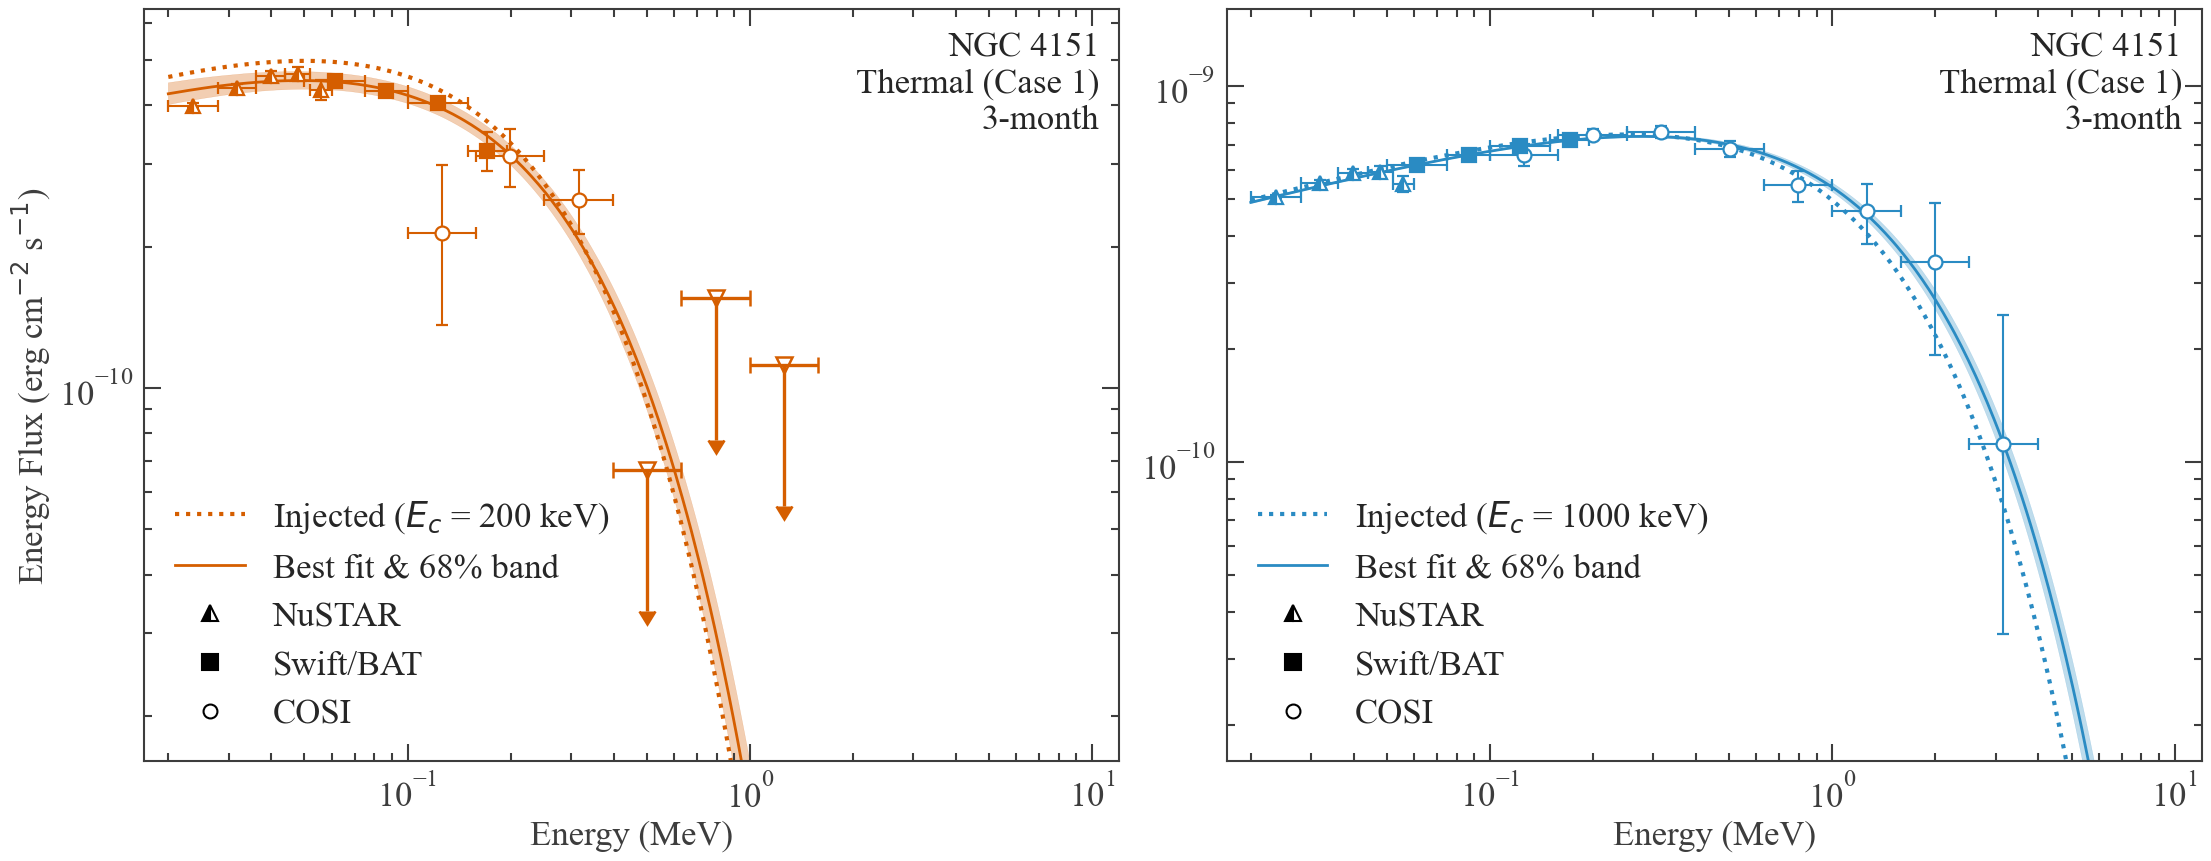

In [30]:
from agn_sed_ensemble import classify_representative_sed

# Plot A uses only the selected representative realization. Its own
# per-bin TS decides detection/upper limit/omission; no 300-seed
# bin-median statistic enters this plot.
representative_thermal_cosi_sed_df_ec1000 = classify_representative_sed(thermal_cosi_sed_df_ec1000, detection_ts=4.0)
representative_thermal_cosi_sed_df = classify_representative_sed(thermal_cosi_sed_df, detection_ts=4.0)

print('Plot A: representative median data set; classification uses its own bin TS.')
FONT_SIZE = 25

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update(
    {
        "font.weight": "550",
        "axes.titleweight": "550",
        "axes.labelweight": "550",
    }
)

def _make_xerr(df):
    return KEV_TO_MEV * np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )


def _split_sed_detections(df, ts_threshold=4.0, min_plot_ts=1.0):
    if 'plot_role' in df.columns:
        roles = df['plot_role'].astype(str)
        return (
            df.loc[roles == 'detection'].copy(),
            df.loc[roles == 'upper_limit'].copy(),
        )

    plot_mask = np.ones(len(df), dtype=bool)
    upper_limit_mask = df['is_upper_limit'].copy()

    if 'ts_value' in df.columns:
        plot_mask = df['ts_value'] >= min_plot_ts
        upper_limit_mask = upper_limit_mask | (df['ts_value'] < ts_threshold)

    return (
        df.loc[plot_mask & ~upper_limit_mask].copy(),
        df.loc[plot_mask & upper_limit_mask].copy(),
    )


def _plot_sed_points(ax, det, ul, marker, color, facecolor, label, markersize=10, fillstyle='full'):
    if not det.empty:
        detection_yerr = np.vstack(
            [
                np.maximum(det['sed_erg_cm2_s'] - det['sed_lo_erg_cm2_s'], 0),
                np.maximum(det['sed_hi_erg_cm2_s'] - det['sed_erg_cm2_s'], 0),
            ]
        )

        ax.errorbar(
            det['e_ref_keV'] * KEV_TO_MEV,
            det['sed_erg_cm2_s'],
            xerr=_make_xerr(det),
            yerr=detection_yerr,
            fmt=marker,
            color=color,
            ecolor=color,
            markerfacecolor=facecolor,
            markerfacecoloralt='white',
            markeredgecolor=color,
            markeredgewidth=1.6,
            fillstyle=fillstyle,
            elinewidth=1.5,
            capsize=4,
            markersize=markersize,
            label=label,
        )

    if not ul.empty:
        upper_y = ul['sed_hi_erg_cm2_s'].to_numpy()
        upper_yerr = np.maximum(0.5 * upper_y, np.finfo(float).tiny)

        ax.errorbar(
            ul['e_ref_keV'] * KEV_TO_MEV,
            upper_y,
            xerr=_make_xerr(ul),
            yerr=upper_yerr,
            uplims=True,
            fmt='v',
            color=color,
            ecolor=color,
            markerfacecolor='white',
            markeredgecolor=color,
            markeredgewidth=1.8,
            elinewidth=2.4,
            capsize=6,
            markersize=11,
            barsabove=True,
            zorder=6,
            label='_nolegend_',
        )


def _fit_includes_dataset(fit_results, dataset_name):
    try:
        return dataset_name in fit_results.get_statistic_frame().index
    except Exception:
        return False

has_bat_fit_200 = _fit_includes_dataset(results, 'BAT')
has_bat_fit_1000 = _fit_includes_dataset(results_ec1000, 'BAT')
has_nustar_fit_200 = any(
    _fit_includes_dataset(results, dataset_name)
    for dataset_name in ('nustar_fpma', 'nustar_fpmb', 'NuSTAR', 'FPMA', 'FPMB')
)
has_nustar_fit_1000 = any(
    _fit_includes_dataset(results_ec1000, dataset_name)
    for dataset_name in ('nustar_fpma', 'nustar_fpmb', 'NuSTAR', 'FPMA', 'FPMB')
)
has_any_xray_fit = has_bat_fit_200 or has_bat_fit_1000 or has_nustar_fit_200 or has_nustar_fit_1000
fit_label = 'Global joint fit' if has_any_xray_fit else 'Global COSI-only fit'
fit_suffix = 'Joint' if has_any_xray_fit else 'COSI'

n_cosi_sed_bins_200 = len(representative_thermal_cosi_sed_df)
n_cosi_sed_bins_1000 = len(representative_thermal_cosi_sed_df_ec1000)

joint_sed_sources = [
    {
        'instrument': 'NuSTAR',
        'fit_200': has_nustar_fit_200,
        'fit_1000': has_nustar_fit_1000,
        'df_names_200': ('thermal_nustar_sed_df', 'thermal_nustar_fpma_sed_df', 'thermal_nustar_fpmb_sed_df'),
        'df_names_1000': ('thermal_nustar_sed_df_ec1000', 'thermal_nustar_fpma_sed_df_ec1000', 'thermal_nustar_fpmb_sed_df_ec1000'),
        'marker': '^',
        'fillstyle': 'left',
    },
    {
        'instrument': 'BAT',
        'fit_200': 'thermal_bat_sed_df_60_200' in globals(),
        'fit_1000': 'thermal_bat_sed_df_ec1000_60_200' in globals(),
        'df_names_200': ('thermal_bat_sed_df_60_200',),
        'df_names_1000': ('thermal_bat_sed_df_ec1000_60_200',),
        'marker': 's',
        'fillstyle': 'full',
    },
]


def _loaded_sed_dataframe(df_names):
    if df_names and df_names[0] in globals():
        return globals()[df_names[0]]

    sed_frames = [globals()[df_name] for df_name in df_names[1:] if df_name in globals()]

    if not sed_frames:
        return pd.DataFrame()

    if len(sed_frames) == 1:
        return sed_frames[0]

    return pd.concat(sed_frames, ignore_index=True)


def _combine_sed_rows_for_plot(bin_rows):
    row = bin_rows.iloc[0].copy()
    row['e_min_keV'] = float(bin_rows['e_min_keV'].min())
    row['e_max_keV'] = float(bin_rows['e_max_keV'].max())
    row['e_ref_keV'] = float(np.sqrt(row['e_min_keV'] * row['e_max_keV']))
    row['channel_number'] = f"{bin_rows['channel_number'].iloc[0]}-{bin_rows['channel_number'].iloc[-1]}"

    for column in ('data_counts', 'background_counts', 'excess_counts'):
        if column in bin_rows.columns:
            row[column] = float(bin_rows[column].sum())

    for column in ('joint_statistic', 'joint_null_statistic', 'ts_value_raw', 'ts_value'):
        if column in bin_rows.columns:
            row[column] = float(bin_rows[column].sum())

    if 'ts_value' in bin_rows.columns:
        row['sigma'] = _ts_to_sigma(row['ts_value'])

    for column in (
        'bin_energy_flux_erg_cm2_s',
        'bin_energy_flux_lo_erg_cm2_s',
        'bin_energy_flux_hi_erg_cm2_s',
        'sed_erg_cm2_s',
        'sed_lo_erg_cm2_s',
        'sed_hi_erg_cm2_s',
    ):
        if column in bin_rows.columns:
            row[column] = float(bin_rows[column].mean())

    if 'is_upper_limit' in bin_rows.columns:
        row['is_upper_limit'] = bool(bin_rows['is_upper_limit'].all())

    return row


def _limit_sed_dataframe_for_plot(sed_df, max_bins=4):
    if len(sed_df) <= max_bins:
        return sed_df

    sorted_sed = sed_df.sort_values('e_ref_keV').reset_index(drop=True)
    plot_rows = [
        _combine_sed_rows_for_plot(group)
        for group in np.array_split(sorted_sed, int(max_bins))
    ]
    return pd.DataFrame(plot_rows).reset_index(drop=True)


def _make_joint_sed_entries(ec_label, color):
    entries = []

    for source in joint_sed_sources:
        if not source[f'fit_{ec_label}']:
            continue

        sed_df = _loaded_sed_dataframe(source[f'df_names_{ec_label}'])
        if sed_df.empty:
            continue

        det, ul = _split_sed_detections(sed_df)
        entries.append(
            {
                'instrument': source['instrument'],
                'ec_label': ec_label,
                'color': color,
                'facecolor': color,
                'marker': source['marker'],
                'fillstyle': source['fillstyle'],
                'det': det,
                'ul': ul,
                'n_bins': len(sed_df),
            }
        )

    return entries

det_cosi_200, ul_cosi_200 = _split_sed_detections(representative_thermal_cosi_sed_df)
det_cosi_1000, ul_cosi_1000 = _split_sed_detections(representative_thermal_cosi_sed_df_ec1000)

joint_sed_entries_200 = _make_joint_sed_entries('200', color='#D55E00')
joint_sed_entries_1000 = _make_joint_sed_entries('1000', color='#2A8BC3')

# Set the y-axis limits for each cutoff panel independently.
y_limits_200 = (1e-2 * SED_KEV_TO_ERG, 4e-1 * SED_KEV_TO_ERG)
y_limits_1000 = (1e-2 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)

panel_configs = [
    {
        'ec_label': '200',
        'color': '#D55E00',
        'flux_inj': flux_inj,
        'flux_median': flux_median,
        'flux_lo': flux_lo,
        'flux_hi': flux_hi,
        'det_cosi': det_cosi_200,
        'ul_cosi': ul_cosi_200,
        'n_cosi_bins': n_cosi_sed_bins_200,
        'joint_entries': joint_sed_entries_200,
        'y_limits': y_limits_200,
    },
    {
        'ec_label': '1000',
        'color': '#2A8BC3',
        'flux_inj': flux_inj_ec1000,
        'flux_median': flux_median_ec1000,
        'flux_lo': flux_lo_ec1000,
        'flux_hi': flux_hi_ec1000,
        'det_cosi': det_cosi_1000,
        'ul_cosi': ul_cosi_1000,
        'n_cosi_bins': n_cosi_sed_bins_1000,
        'joint_entries': joint_sed_entries_1000,
        'y_limits': y_limits_1000,
    },
]

fig, axes = plt.subplots(1, 2, figsize=(22, 8.5), sharex=True, sharey=False, constrained_layout=True)

for ax, panel in zip(axes, panel_configs):
    color = panel['color']
    ec_label = panel['ec_label']

    ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
    ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)

    ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy * energy * panel['flux_inj'],
        color=color,
        ls=':',
        lw=3,
    )
    ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy * energy * panel['flux_median'],
        color=color,
        lw=2,
    )
    ax.fill_between(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy * energy * panel['flux_lo'],
        SED_KEV_TO_ERG * energy * energy * panel['flux_hi'],
        alpha=0.3,
        color=color,
    )

    _plot_sed_points(
        ax,
        panel['det_cosi'],
        panel['ul_cosi'],
        marker='o',
        color=color,
        facecolor='white',
        fillstyle='full',
        label='_nolegend_',
    )

    for joint_entry in panel['joint_entries']:
        _plot_sed_points(
            ax,
            joint_entry['det'],
            joint_entry['ul'],
            marker=joint_entry['marker'],
            color=color,
            facecolor=color,
            label='_nolegend_',
            markersize=10,
            fillstyle=joint_entry['fillstyle'],
        )

    instrument_labels = {
        'NuSTAR': 'NuSTAR',
        'BAT': 'Swift/BAT',
    }

    # Add model labels first.
    legend_handles = [
        plt.Line2D(
            [],
            [],
            color=color,
            linestyle=':',
            linewidth=3,
            label=rf'Injected ($E_c$ = {ec_label} keV)',
        ),
        plt.Line2D(
            [],
            [],
            color=color,
            linewidth=2,
            label='Best fit & 68% band',
        ),
    ]

    # Add NuSTAR followed by Swift/BAT.
    for instrument_name in ('NuSTAR', 'BAT'):
        for joint_entry in panel['joint_entries']:
            if joint_entry['instrument'] != instrument_name:
                continue

            if joint_entry['det'].empty and joint_entry['ul'].empty:
                continue

            legend_handles.append(
                plt.Line2D(
                    [],
                    [],
                    color='black',
                    marker=joint_entry['marker'],
                    markerfacecolor='black',
                    markerfacecoloralt='white',
                    markeredgecolor='black',
                    markeredgewidth=1.5,
                    fillstyle=joint_entry['fillstyle'],
                    linestyle='None',
                    markersize=12,
                    label=instrument_labels[instrument_name],
                )
            )
            break

    # Add COSI last.
    if not panel['det_cosi'].empty or not panel['ul_cosi'].empty:
        legend_handles.append(
            plt.Line2D(
                [],
                [],
                color='black',
                marker='o',
                markerfacecolor='white',
                markeredgecolor='black',
                markeredgewidth=1.5,
                linestyle='None',
                markersize=10,
                label='COSI',
            )
        )

    ax.text(
        0.98, 0.97,
        f'NGC 4151\nThermal (Case 1)\n{exposure_4151}-month',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=FONT_SIZE,
        fontweight='550',
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim((flux_energy_min_keV-3) * KEV_TO_MEV, (flux_energy_max_keV+2000) * KEV_TO_MEV)
    ax.set_ylim(*panel['y_limits'])
    ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
    ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

axes[0].set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)

save_path = f'/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_ThModel_TH_200_1000_{exposure_4151}Months_BAT_NuSTAR_COSI_SED_RepresentativeMedianDataset.pdf'
plt.savefig(save_path)
plt.show()


### Plot B — 300-seed median SED

SED bin values and point/upper-limit decisions come from the 300-seed bin-by-bin ensemble medians.


In [31]:
from agn_sed_ensemble import (
    ensemble_summary_to_sed_dataframe,
    run_or_load_manifest_sed_ensemble,
)

SED_ENSEMBLE_RECOMPUTE = False
SED_ENSEMBLE_PSEUDOCOUNT = globals().get('BACKGROUND_PSEUDOCOUNT', None)

_, ec200_sed_summary, _, ec200_sed_summary_file = run_or_load_manifest_sed_ensemble(
    manifest=ec200_manifest, source_expectation=NGC4151_ec200,
    background_expectation=bkg, injected_shape=spectrum_inj_ec200,
    n_sed_bins=len(thermal_cosi_sed_df), background_pseudocount=SED_ENSEMBLE_PSEUDOCOUNT,
    recompute=SED_ENSEMBLE_RECOMPUTE,
)
_, ec1000_sed_summary, _, ec1000_sed_summary_file = run_or_load_manifest_sed_ensemble(
    manifest=ec1000_manifest, source_expectation=NGC4151_ec1000,
    background_expectation=bkg, injected_shape=spectrum_inj_ec1000,
    n_sed_bins=len(thermal_cosi_sed_df_ec1000), background_pseudocount=SED_ENSEMBLE_PSEUDOCOUNT,
    recompute=SED_ENSEMBLE_RECOMPUTE,
)
ensemble_thermal_cosi_sed_df = ensemble_summary_to_sed_dataframe(ec200_sed_summary)
ensemble_thermal_cosi_sed_df_ec1000 = ensemble_summary_to_sed_dataframe(ec1000_sed_summary)
display(ec200_sed_summary[['bin_index', 'ts_median', 'source_scale_q16', 'plot_role']])
display(ec1000_sed_summary[['bin_index', 'ts_median', 'source_scale_q16', 'plot_role']])


,bin_index,ts_median,source_scale_q16,plot_role
0,1,1495.878804,0.893947,detection
1,2,161.507641,0.913608,detection
2,3,1440.688415,0.884979,detection
3,4,8.328327,0.643429,detection
4,5,0.216208,0.000000,upper_limit
5,6,0.000354,0.000000,upper_limit
6,7,0.000000,0.000000,omitted
7,8,0.000000,0.000000,omitted


,bin_index,ts_median,source_scale_q16,plot_role
0,1,3120.176539,0.933125,detection
1,2,2187.026183,0.967813,detection
2,3,4963.423225,0.958631,detection
3,4,1833.178291,0.950349,detection
4,5,163.729034,0.916773,detection
5,6,29.293391,0.804276,detection
6,7,3.429765,0.267725,upper_limit
7,8,0.000000,0.000000,omitted
8,9,0.000000,0.000000,omitted
9,10,0.000000,0.000000,omitted


Plot B: 300-seed ensemble median SED; classification uses median bin TS.


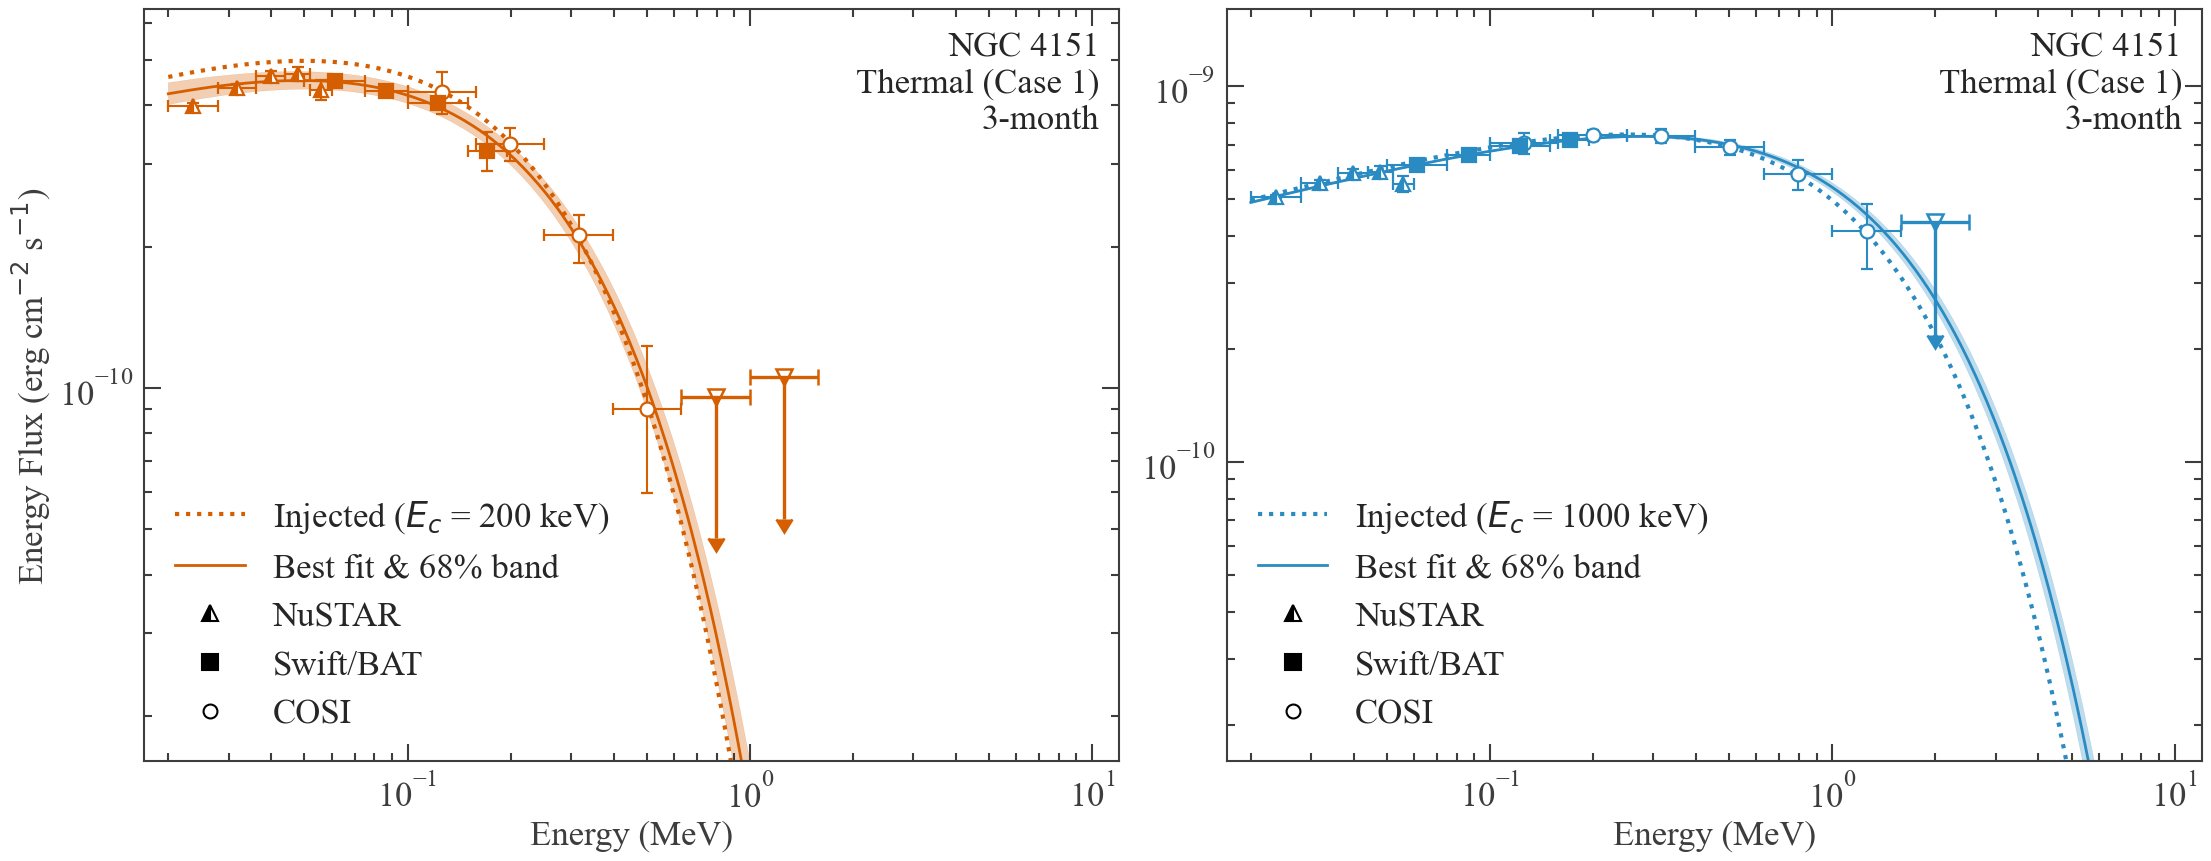

In [32]:
# Plot B uses the bin-by-bin median flux and median TS from all 300 seeds.
print('Plot B: 300-seed ensemble median SED; classification uses median bin TS.')

FONT_SIZE = 25

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update(
    {
        "font.weight": "550",
        "axes.titleweight": "550",
        "axes.labelweight": "550",
    }
)

def _make_xerr(df):
    return KEV_TO_MEV * np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )


def _split_sed_detections(df, ts_threshold=4.0, min_plot_ts=1.0):
    if 'plot_role' in df.columns:
        roles = df['plot_role'].astype(str)
        return (
            df.loc[roles == 'detection'].copy(),
            df.loc[roles == 'upper_limit'].copy(),
        )

    plot_mask = np.ones(len(df), dtype=bool)
    upper_limit_mask = df['is_upper_limit'].copy()

    if 'ts_value' in df.columns:
        plot_mask = df['ts_value'] >= min_plot_ts
        upper_limit_mask = upper_limit_mask | (df['ts_value'] < ts_threshold)

    return (
        df.loc[plot_mask & ~upper_limit_mask].copy(),
        df.loc[plot_mask & upper_limit_mask].copy(),
    )


def _plot_sed_points(ax, det, ul, marker, color, facecolor, label, markersize=10, fillstyle='full'):
    if not det.empty:
        detection_yerr = np.vstack(
            [
                np.maximum(det['sed_erg_cm2_s'] - det['sed_lo_erg_cm2_s'], 0),
                np.maximum(det['sed_hi_erg_cm2_s'] - det['sed_erg_cm2_s'], 0),
            ]
        )

        ax.errorbar(
            det['e_ref_keV'] * KEV_TO_MEV,
            det['sed_erg_cm2_s'],
            xerr=_make_xerr(det),
            yerr=detection_yerr,
            fmt=marker,
            color=color,
            ecolor=color,
            markerfacecolor=facecolor,
            markerfacecoloralt='white',
            markeredgecolor=color,
            markeredgewidth=1.6,
            fillstyle=fillstyle,
            elinewidth=1.5,
            capsize=4,
            markersize=markersize,
            label=label,
        )

    if not ul.empty:
        upper_y = ul['sed_hi_erg_cm2_s'].to_numpy()
        upper_yerr = np.maximum(0.5 * upper_y, np.finfo(float).tiny)

        ax.errorbar(
            ul['e_ref_keV'] * KEV_TO_MEV,
            upper_y,
            xerr=_make_xerr(ul),
            yerr=upper_yerr,
            uplims=True,
            fmt='v',
            color=color,
            ecolor=color,
            markerfacecolor='white',
            markeredgecolor=color,
            markeredgewidth=1.8,
            elinewidth=2.4,
            capsize=6,
            markersize=11,
            barsabove=True,
            zorder=6,
            label='_nolegend_',
        )


def _fit_includes_dataset(fit_results, dataset_name):
    try:
        return dataset_name in fit_results.get_statistic_frame().index
    except Exception:
        return False

has_bat_fit_200 = _fit_includes_dataset(results, 'BAT')
has_bat_fit_1000 = _fit_includes_dataset(results_ec1000, 'BAT')
has_nustar_fit_200 = any(
    _fit_includes_dataset(results, dataset_name)
    for dataset_name in ('nustar_fpma', 'nustar_fpmb', 'NuSTAR', 'FPMA', 'FPMB')
)
has_nustar_fit_1000 = any(
    _fit_includes_dataset(results_ec1000, dataset_name)
    for dataset_name in ('nustar_fpma', 'nustar_fpmb', 'NuSTAR', 'FPMA', 'FPMB')
)
has_any_xray_fit = has_bat_fit_200 or has_bat_fit_1000 or has_nustar_fit_200 or has_nustar_fit_1000
fit_label = 'Global joint fit' if has_any_xray_fit else 'Global COSI-only fit'
fit_suffix = 'Joint' if has_any_xray_fit else 'COSI'

n_cosi_sed_bins_200 = len(ensemble_thermal_cosi_sed_df)
n_cosi_sed_bins_1000 = len(ensemble_thermal_cosi_sed_df_ec1000)

joint_sed_sources = [
    {
        'instrument': 'NuSTAR',
        'fit_200': has_nustar_fit_200,
        'fit_1000': has_nustar_fit_1000,
        'df_names_200': ('thermal_nustar_sed_df', 'thermal_nustar_fpma_sed_df', 'thermal_nustar_fpmb_sed_df'),
        'df_names_1000': ('thermal_nustar_sed_df_ec1000', 'thermal_nustar_fpma_sed_df_ec1000', 'thermal_nustar_fpmb_sed_df_ec1000'),
        'marker': '^',
        'fillstyle': 'left',
    },
    {
        'instrument': 'BAT',
        'fit_200': 'thermal_bat_sed_df_60_200' in globals(),
        'fit_1000': 'thermal_bat_sed_df_ec1000_60_200' in globals(),
        'df_names_200': ('thermal_bat_sed_df_60_200',),
        'df_names_1000': ('thermal_bat_sed_df_ec1000_60_200',),
        'marker': 's',
        'fillstyle': 'full',
    },
]


def _loaded_sed_dataframe(df_names):
    if df_names and df_names[0] in globals():
        return globals()[df_names[0]]

    sed_frames = [globals()[df_name] for df_name in df_names[1:] if df_name in globals()]

    if not sed_frames:
        return pd.DataFrame()

    if len(sed_frames) == 1:
        return sed_frames[0]

    return pd.concat(sed_frames, ignore_index=True)


def _combine_sed_rows_for_plot(bin_rows):
    row = bin_rows.iloc[0].copy()
    row['e_min_keV'] = float(bin_rows['e_min_keV'].min())
    row['e_max_keV'] = float(bin_rows['e_max_keV'].max())
    row['e_ref_keV'] = float(np.sqrt(row['e_min_keV'] * row['e_max_keV']))
    row['channel_number'] = f"{bin_rows['channel_number'].iloc[0]}-{bin_rows['channel_number'].iloc[-1]}"

    for column in ('data_counts', 'background_counts', 'excess_counts'):
        if column in bin_rows.columns:
            row[column] = float(bin_rows[column].sum())

    for column in ('joint_statistic', 'joint_null_statistic', 'ts_value_raw', 'ts_value'):
        if column in bin_rows.columns:
            row[column] = float(bin_rows[column].sum())

    if 'ts_value' in bin_rows.columns:
        row['sigma'] = _ts_to_sigma(row['ts_value'])

    for column in (
        'bin_energy_flux_erg_cm2_s',
        'bin_energy_flux_lo_erg_cm2_s',
        'bin_energy_flux_hi_erg_cm2_s',
        'sed_erg_cm2_s',
        'sed_lo_erg_cm2_s',
        'sed_hi_erg_cm2_s',
    ):
        if column in bin_rows.columns:
            row[column] = float(bin_rows[column].mean())

    if 'is_upper_limit' in bin_rows.columns:
        row['is_upper_limit'] = bool(bin_rows['is_upper_limit'].all())

    return row


def _limit_sed_dataframe_for_plot(sed_df, max_bins=4):
    if len(sed_df) <= max_bins:
        return sed_df

    sorted_sed = sed_df.sort_values('e_ref_keV').reset_index(drop=True)
    plot_rows = [
        _combine_sed_rows_for_plot(group)
        for group in np.array_split(sorted_sed, int(max_bins))
    ]
    return pd.DataFrame(plot_rows).reset_index(drop=True)


def _make_joint_sed_entries(ec_label, color):
    entries = []

    for source in joint_sed_sources:
        if not source[f'fit_{ec_label}']:
            continue

        sed_df = _loaded_sed_dataframe(source[f'df_names_{ec_label}'])
        if sed_df.empty:
            continue

        det, ul = _split_sed_detections(sed_df)
        entries.append(
            {
                'instrument': source['instrument'],
                'ec_label': ec_label,
                'color': color,
                'facecolor': color,
                'marker': source['marker'],
                'fillstyle': source['fillstyle'],
                'det': det,
                'ul': ul,
                'n_bins': len(sed_df),
            }
        )

    return entries

det_cosi_200, ul_cosi_200 = _split_sed_detections(ensemble_thermal_cosi_sed_df)
det_cosi_1000, ul_cosi_1000 = _split_sed_detections(ensemble_thermal_cosi_sed_df_ec1000)

joint_sed_entries_200 = _make_joint_sed_entries('200', color='#D55E00')
joint_sed_entries_1000 = _make_joint_sed_entries('1000', color='#2A8BC3')

# Set the y-axis limits for each cutoff panel independently.
y_limits_200 = (1e-2 * SED_KEV_TO_ERG, 4e-1 * SED_KEV_TO_ERG)
y_limits_1000 = (1e-2 * SED_KEV_TO_ERG, 1 * SED_KEV_TO_ERG)

panel_configs = [
    {
        'ec_label': '200',
        'color': '#D55E00',
        'flux_inj': flux_inj,
        'flux_median': flux_median,
        'flux_lo': flux_lo,
        'flux_hi': flux_hi,
        'det_cosi': det_cosi_200,
        'ul_cosi': ul_cosi_200,
        'n_cosi_bins': n_cosi_sed_bins_200,
        'joint_entries': joint_sed_entries_200,
        'y_limits': y_limits_200,
    },
    {
        'ec_label': '1000',
        'color': '#2A8BC3',
        'flux_inj': flux_inj_ec1000,
        'flux_median': flux_median_ec1000,
        'flux_lo': flux_lo_ec1000,
        'flux_hi': flux_hi_ec1000,
        'det_cosi': det_cosi_1000,
        'ul_cosi': ul_cosi_1000,
        'n_cosi_bins': n_cosi_sed_bins_1000,
        'joint_entries': joint_sed_entries_1000,
        'y_limits': y_limits_1000,
    },
]

fig, axes = plt.subplots(1, 2, figsize=(22, 8.5), sharex=True, sharey=False, constrained_layout=True)

for ax, panel in zip(axes, panel_configs):
    color = panel['color']
    ec_label = panel['ec_label']

    ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
    ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)

    ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy * energy * panel['flux_inj'],
        color=color,
        ls=':',
        lw=3,
    )
    ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy * energy * panel['flux_median'],
        color=color,
        lw=2,
    )
    ax.fill_between(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy * energy * panel['flux_lo'],
        SED_KEV_TO_ERG * energy * energy * panel['flux_hi'],
        alpha=0.3,
        color=color,
    )

    _plot_sed_points(
        ax,
        panel['det_cosi'],
        panel['ul_cosi'],
        marker='o',
        color=color,
        facecolor='white',
        fillstyle='full',
        label='_nolegend_',
    )

    for joint_entry in panel['joint_entries']:
        _plot_sed_points(
            ax,
            joint_entry['det'],
            joint_entry['ul'],
            marker=joint_entry['marker'],
            color=color,
            facecolor=color,
            label='_nolegend_',
            markersize=10,
            fillstyle=joint_entry['fillstyle'],
        )

    instrument_labels = {
        'NuSTAR': 'NuSTAR',
        'BAT': 'Swift/BAT',
    }

    # Add model labels first.
    legend_handles = [
        plt.Line2D(
            [],
            [],
            color=color,
            linestyle=':',
            linewidth=3,
            label=rf'Injected ($E_c$ = {ec_label} keV)',
        ),
        plt.Line2D(
            [],
            [],
            color=color,
            linewidth=2,
            label='Best fit & 68% band',
        ),
    ]

    # Add NuSTAR followed by Swift/BAT.
    for instrument_name in ('NuSTAR', 'BAT'):
        for joint_entry in panel['joint_entries']:
            if joint_entry['instrument'] != instrument_name:
                continue

            if joint_entry['det'].empty and joint_entry['ul'].empty:
                continue

            legend_handles.append(
                plt.Line2D(
                    [],
                    [],
                    color='black',
                    marker=joint_entry['marker'],
                    markerfacecolor='black',
                    markerfacecoloralt='white',
                    markeredgecolor='black',
                    markeredgewidth=1.5,
                    fillstyle=joint_entry['fillstyle'],
                    linestyle='None',
                    markersize=12,
                    label=instrument_labels[instrument_name],
                )
            )
            break

    # Add COSI last.
    if not panel['det_cosi'].empty or not panel['ul_cosi'].empty:
        legend_handles.append(
            plt.Line2D(
                [],
                [],
                color='black',
                marker='o',
                markerfacecolor='white',
                markeredgecolor='black',
                markeredgewidth=1.5,
                linestyle='None',
                markersize=10,
                label='COSI',
            )
        )

    ax.text(
        0.98, 0.97,
        f'NGC 4151\nThermal (Case 1)\n{exposure_4151}-month',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=FONT_SIZE,
        fontweight='550',
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim((flux_energy_min_keV-3) * KEV_TO_MEV, (flux_energy_max_keV+2000) * KEV_TO_MEV)
    ax.set_ylim(*panel['y_limits'])
    ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
    ax.legend(handles=legend_handles, fontsize=FONT_SIZE, loc='lower left', frameon=False)

axes[0].set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)

save_path = f'/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC4151_ThModel_TH_200_1000_{exposure_4151}Months_BAT_NuSTAR_COSI_SED_300SeedMedianSED.pdf'
plt.savefig(save_path)
plt.show()


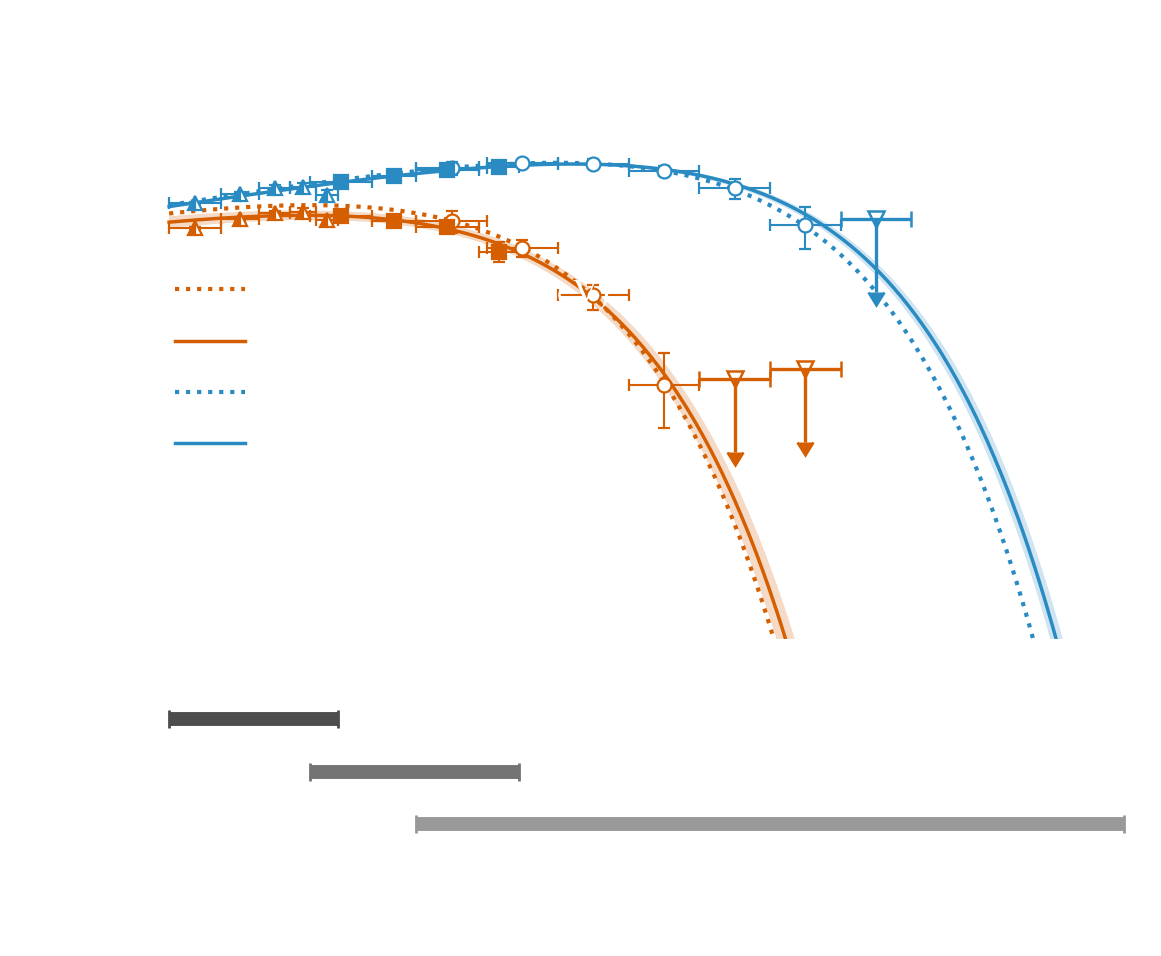

In [33]:
# Overlay both cutoff fits and show the energy coverage of the plotted data.
FONT_SIZE = 25
plt.rcParams['agg.path.chunksize'] = 10000
plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update(
    {
        'font.weight': '550',
        'axes.titleweight': '550',
        'axes.labelweight': '550',
    }
)


def _apply_transparent_plot_style(fig, ax):
    foreground_color = 'white'

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    ax.tick_params(axis='both', which='both', colors=foreground_color)
    ax.xaxis.label.set_color(foreground_color)
    ax.yaxis.label.set_color(foreground_color)

    for spine in ax.spines.values():
        spine.set_color(foreground_color)

    for annotation in ax.texts:
        annotation.set_color(foreground_color)

    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_alpha(0)
        legend.get_frame().set_edgecolor(foreground_color)
        for legend_text in legend.get_texts():
            legend_text.set_color(foreground_color)


def _plotted_instrument_rows(instrument):
    frames = []

    for panel in panel_configs:
        if instrument == 'COSI':
            frames.extend([panel['det_cosi'], panel['ul_cosi']])
            continue

        for entry in panel['joint_entries']:
            if entry['instrument'] == instrument:
                frames.extend([entry['det'], entry['ul']])

    frames = [frame for frame in frames if not frame.empty]
    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


fig, (ax, range_ax) = plt.subplots(
    2,
    1,
    figsize=(13, 11),
    sharex=True,
    gridspec_kw={'height_ratios': [5, 1.55], 'hspace': 0.05},
)

for axis in (ax, range_ax):
    axis.spines['right'].set_visible(True)
    axis.spines['top'].set_visible(True)
    axis.xaxis.set_tick_params(
        which='major', size=12, width=1.5, direction='in', top=True,
        pad=8, labelsize=FONT_SIZE,
    )
    axis.xaxis.set_tick_params(
        which='minor', size=6, width=1.5, direction='in', top=True,
        pad=8,
    )

ax.yaxis.set_tick_params(
    which='major', size=12, width=1.5, direction='in', right=True,
    pad=8, labelsize=FONT_SIZE,
)
ax.yaxis.set_tick_params(
    which='minor', size=6, width=1.5, direction='in', right=True,
    pad=8,
)

# Color identifies the cutoff case; marker shape identifies the instrument.
for panel in panel_configs:
    color = panel['color']
    ec_label = panel['ec_label']

    ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_inj'],
        color=color,
        linestyle=':',
        lw=3,
        label=rf'Injected ($E_c$ = {ec_label} keV)',
    )
    ax.plot(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_median'],
        color=color,
        lw=2.5,
        label=rf'Best fit & 68% band',
    )
    ax.fill_between(
        energy * KEV_TO_MEV,
        SED_KEV_TO_ERG * energy**2 * panel['flux_lo'],
        SED_KEV_TO_ERG * energy**2 * panel['flux_hi'],
        color=color,
        alpha=0.22,
    )

    _plot_sed_points(
        ax,
        panel['det_cosi'],
        panel['ul_cosi'],
        marker='o',
        color=color,
        facecolor='white',
        fillstyle='full',
        label='_nolegend_',
    )

    for entry in panel['joint_entries']:
        _plot_sed_points(
            ax,
            entry['det'],
            entry['ul'],
            marker=entry['marker'],
            color=color,
            facecolor=color,
            fillstyle=entry['fillstyle'],
            label='_nolegend_',
        )

instrument_handles = [
    plt.Line2D(
        [], [], color='white', marker='^', markerfacecolor='white',
        markerfacecoloralt='none', markeredgecolor='white',
        markeredgewidth=1.5, fillstyle='left', linestyle='None',
        markersize=12, label='NuSTAR',
    ),
    plt.Line2D(
        [], [], color='white', marker='s', markerfacecolor='white',
        markeredgecolor='white', markeredgewidth=1.5,
        linestyle='None', markersize=12, label='Swift/BAT',
    ),
    plt.Line2D(
        [], [], color='white', marker='o', markerfacecolor='none',
        markeredgecolor='white', markeredgewidth=1.5,
        linestyle='None', markersize=10, label='COSI',
    ),
]
model_handles, model_labels = ax.get_legend_handles_labels()
ax.legend(
    handles=model_handles + instrument_handles,
    labels=model_labels + [handle.get_label() for handle in instrument_handles],
    fontsize=FONT_SIZE,
    loc='lower left',
    frameon=False,
)

ax.text(
    0.98, 0.97,
    f'NGC 4151\nThermal (Case 1)\n{exposure_4151}-month',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550',
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(
    (flux_energy_min_keV - 3) * KEV_TO_MEV,
    (flux_energy_max_keV + 2000) * KEV_TO_MEV,
)
ax.set_ylim(
    min(panel['y_limits'][0] for panel in panel_configs) / 2,
    max(panel['y_limits'][1] for panel in panel_configs) * 2,
)
ax.set_ylabel(r'Energy Flux (erg cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.tick_params(axis='x', which='both', labelbottom=False)

# Derive coverage from the edges of the data bins that are actually plotted.
coverage_specs = [
    ('NuSTAR', 'NuSTAR', '#4D4D4D'),
    ('BAT', 'Swift/BAT', '#737373'),
    ('COSI', 'COSI', '#999999'),
]
coverage_rows = []
for instrument, label, bar_color in coverage_specs:
    plotted_rows = _plotted_instrument_rows(instrument)
    if plotted_rows.empty:
        continue

    e_min_keV = plotted_rows['e_min_keV'].min()
    e_max_keV = plotted_rows['e_max_keV'].max()
    if instrument == 'COSI':
        e_min_keV, e_max_keV = 100.0, 10000.0

    coverage_rows.append(
        {
            'label': label,
            'color': bar_color,
            'e_min_keV': e_min_keV,
            'e_max_keV': e_max_keV,
        }
    )

for y, coverage in zip(
    np.arange(len(coverage_rows), dtype=float)[::-1] + 0.5,
    coverage_rows,
):
    e_min_mev = coverage['e_min_keV'] * KEV_TO_MEV
    e_max_mev = coverage['e_max_keV'] * KEV_TO_MEV
    e_center_mev = np.sqrt(e_min_mev * e_max_mev)

    range_ax.plot(
        [e_min_mev, e_max_mev], [y, y],
        color=coverage['color'], lw=10, solid_capstyle='butt',
    )
    range_ax.plot(
        [e_min_mev, e_max_mev], [y, y],
        linestyle='None', marker='|', markersize=13,
        markeredgewidth=2, color=coverage['color'],
    )
    range_ax.text(
        e_center_mev, y + 0.19,
        (
            f"{coverage['label']}: "
            f"{coverage['e_min_keV']:.0f}-{coverage['e_max_keV']:.0f} keV"
        ),
        ha='center', va='bottom', fontsize=FONT_SIZE-7,
        color='black', fontweight='550',
    )

range_ax.set_xscale('log')
range_ax.set_ylim(-0.1, max(len(coverage_rows), 1) + 0.6)
range_ax.set_yticks([])
range_ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
range_ax.set_ylabel('Coverage', fontsize=FONT_SIZE)

fig.align_ylabels([ax, range_ax])
_apply_transparent_plot_style(fig, ax)
_apply_transparent_plot_style(fig, range_ax)
plt.show()